# 02 Objective Windows
Explore the objective-window table: outcome distributions, setup profiles, feature correlations with securing the objective.

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
if str(repo_root / 'src') not in sys.path:
    sys.path.insert(0, str(repo_root / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 4)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

from lolobj.config import PROCESSED_DIR

parquet_path = PROCESSED_DIR / 'objective_windows.parquet'
df = pd.read_parquet(parquet_path)
print(f'Loaded {len(df)} rows, {df["match_id"].nunique()} matches')
df.head(3)

Loaded 68334 rows, 3839 matches


,match_id,objective_instance,objective_type,objective_number,objective_time_ms,team_id,team_side,rank_bucket,patch,monster_subtype,...,control_wards_T_60,enemy_wards_placed_T_30,enemy_wards_placed_T_60,xp_diff_T_30,xp_diff_T_60,avg_level_diff_T_30,cs_diff_T_30,cs_diff_T_60,gold_spent_diff_T_30,gold_spent_diff_T_60
0,EUW1_7108550527,voidgrub_1,HORDE,1,401903,100,blue,low,14.17.615.2328,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EUW1_7108550527,voidgrub_1,HORDE,1,401903,200,red,low,14.17.615.2328,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EUW1_7108550527,voidgrub_2,HORDE,2,408315,100,blue,low,14.17.615.2328,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Reference: definitions

All definitions below are drawn directly from source code. If the implementation changes, update this section.

---

### Outcome labels
*Source: `src/lolobj/labels/objective_outcomes.py` → `classify_outcome`*

One row per team per objective spawn. Rules are applied in **priority order** — the first match wins.

Shared parameters:
- **nearby** = within 2 500 units of objective center (measured at T−30s)
- **fight window** = [T−30s, T+30s]
- **pre-obj deaths** = allied deaths in [T−30s, T)
- **aftermath** = [T, T+120s]
- **aftermath trade gain** = this team destroyed ≥1 tower **or** secured ≥1 elite monster in [T, T+120s]

| Priority | Label | Trigger condition |
|---|---|---|
| 1 | `no_meaningful_contest` | Neither team nearby at T−30s |
| 2 | `objective_steal` | Team **absent** at T−30s but secured (smite/arrive from outside radius) |
| 3 | `good_trade` | Team absent at T−30s; not secured; **aftermath trade gain** |
| 4 | `clean_give` | Team absent at T−30s; not secured; no aftermath trade |
| 5 | `objective_steal` | Team present; secured; `enemy_nearby ≥ team_nearby + 2` |
| 6 | `lost_fight_got_objective` | Team present; secured; deaths > kills in fight window |
| 7 | `won_fight_lost_objective` | Team present; not secured; kills > deaths in fight window |
| 8 | `throw_setup` | Team present; not secured; ≥1 pre-obj deaths; deaths ≥ kills in fight window |
| 9 | `good_trade` | Team present; not secured; kills ≤ deaths in fight; **aftermath trade gain** |
| 10 | `bad_contest` | Team present; not secured; kills ≤ deaths; no aftermath trade |
| 11 | `coinflip` | Secured; enemy present; `|team_nearby − enemy_nearby| ≤ 1`; `|kills − deaths| ≤ 1` in fight |
| 12 | `clean_take` | Secured; all above conditions unmet |

---

### Setup profiles
*Source: `src/lolobj/analysis/baseline_report.py` → `assign_setup_profiles`*

Profiles compare **this team vs the opponent at T−30s**. Rules are exclusive and exhaustive.

Parameters differ from outcome-label parameters:
- `team_nearby_T_30` = allied champions within 2 500u at T−30s
- `team_deaths_60s` = allied deaths in **[T−60s, T)** ← wider window than outcome-label pre_obj_deaths

| Profile | Condition |
|---|---|
| `no_early_setup` | `team_nearby_T_30 == 0` AND `enemy_nearby_T_30 == 0` |
| `gave_away` | `team_nearby_T_30 == 0` AND `enemy_nearby_T_30 ≥ 1` |
| `free_setup` | `team_nearby_T_30 ≥ 1` AND `enemy_nearby_T_30 == 0` AND `team_deaths_60s == 0` |
| `free_setup_deaths` | `team_nearby_T_30 ≥ 1` AND `enemy_nearby_T_30 == 0` AND `team_deaths_60s ≥ 1` |
| `disadvantaged` | Both teams present AND (`team_deaths_60s ≥ 1` OR `team_alive_T_30 < enemy_alive_T_30`) |
| `clean_contest` | Both teams present AND `team_deaths_60s == 0` AND `team_alive_T_30 ≥ enemy_alive_T_30` |

---

### Trade: definition

A **trade** is detected from aftermath events in [T, T+120s]:

```
meaningful_trade = (towers_destroyed_by_team ≥ 1)  OR  (elite_monsters_secured ≥ 1)
```

Covers `BUILDING_KILL` of type `TOWER_BUILDING` and `ELITE_MONSTER_KILL` attributed to this team. Plate destroys also count (`TURRET_PLATE_DESTROYED`). Does **not** include kills or gold — only map-objective gains.

---

### Good trade: definition

`good_trade` is assigned when **meaningful_trade is true** AND this team either:
- was **absent** from the objective (rows 3 in the table above), or
- was **present but failed** to secure with no clear wins in the fight (row 9)

A `clean_give` is the absent case without a trade. A `bad_contest` is the present-and-failed case without a trade. The only difference between `bad_contest` and `good_trade` is whether the aftermath gained map value.

## Feature filtering — temporal redundancy analysis

Run this before any other analysis. It drops features that have near-zero signal or are near-duplicates of a better sibling, and defines `FEATURES_KEEP` used by all subsequent feature-based cells.

**Drop criteria:**
- `|corr| < 0.05` with `secured` — essentially no signal
- inter-corr > 0.85 with a sibling that has stronger target correlation — redundant

In [2]:
_CANDIDATE_FEATURES = [
    # Arrival / presence
    'arrived_first',
    'team_nearby_T_90', 'team_nearby_T_60', 'team_nearby_T_30',
    'enemy_nearby_T_90', 'enemy_nearby_T_60', 'enemy_nearby_T_30',
    # Alive counts
    'team_alive_T_30', 'team_alive_T_60',
    'enemy_alive_T_30', 'enemy_alive_T_60',
    'jungler_alive_T_30', 'jungler_alive_T_60',
    'support_alive_T_30', 'support_alive_T_60',
    # Deaths
    'team_deaths_30s', 'team_deaths_60s', 'team_deaths_90s',
    'enemy_deaths_30s', 'enemy_deaths_60s',
    # Gold / combat power
    'gold_diff_T_30', 'gold_diff_T_60',
    'jungler_level_diff_T_30', 'jungler_level_diff_T_60',
    # Wallet advantage
    'xp_diff_T_30', 'xp_diff_T_60',
    'avg_level_diff_T_30',
    'cs_diff_T_30', 'cs_diff_T_60',
    'gold_spent_diff_T_30', 'gold_spent_diff_T_60',
    # Vision -- T-30 and T-60 windows
    'wards_placed_T_30', 'wards_placed_T_60',
    'wards_killed_T_30', 'wards_killed_T_60',
    'control_wards_T_30', 'control_wards_T_60',
    'enemy_wards_placed_T_30', 'enemy_wards_placed_T_60',
    # Prior context
    'previous_same_obj_team', 'previous_same_obj_enemy',
    # Unspent gold
    'team_unspent_gold_T_30', 'team_unspent_gold_T_60',
    'jungler_unspent_gold_T_30', 'support_unspent_gold_T_30',
    'adc_unspent_gold_T_30', 'mid_unspent_gold_T_30', 'top_unspent_gold_T_30',
]
_CANDIDATE_FEATURES = [c for c in _CANDIDATE_FEATURES if c in df.columns]

target_corr = df[_CANDIDATE_FEATURES + ['secured']].corr()['secured'].drop('secured')

# Step 1: drop weak signal (|corr| < 0.05)
WEAK_SIGNAL_THRESHOLD = 0.05
weak_drop = {c for c, v in target_corr.items() if abs(v) < WEAK_SIGNAL_THRESHOLD}

# Step 2: drop redundant sibling (inter-corr > 0.85, weaker target corr)
REDUNDANT_THRESHOLD = 0.85
_families = {
    'team_nearby':        ['team_nearby_T_90', 'team_nearby_T_60', 'team_nearby_T_30'],
    'enemy_nearby':       ['enemy_nearby_T_90', 'enemy_nearby_T_60', 'enemy_nearby_T_30'],
    'team_alive':         ['team_alive_T_60', 'team_alive_T_30'],
    'enemy_alive':        ['enemy_alive_T_60', 'enemy_alive_T_30'],
    'jungler_alive':      ['jungler_alive_T_60', 'jungler_alive_T_30'],
    'support_alive':      ['support_alive_T_60', 'support_alive_T_30'],
    'team_deaths':        ['team_deaths_90s', 'team_deaths_60s', 'team_deaths_30s'],
    'enemy_deaths':       ['enemy_deaths_60s', 'enemy_deaths_30s'],
    'gold_diff':          ['gold_diff_T_60', 'gold_diff_T_30'],
    'gold_spent_diff':    ['gold_spent_diff_T_60', 'gold_spent_diff_T_30'],
    'xp_diff':            ['xp_diff_T_60', 'xp_diff_T_30'],
    'cs_diff':            ['cs_diff_T_60', 'cs_diff_T_30'],
    'jg_level_diff':      ['jungler_level_diff_T_60', 'jungler_level_diff_T_30'],
    'team_unspent_gold':  ['team_unspent_gold_T_60', 'team_unspent_gold_T_30'],
    'wards_placed':       ['wards_placed_T_60', 'wards_placed_T_30'],
    'wards_killed':       ['wards_killed_T_60', 'wards_killed_T_30'],
    'control_wards':      ['control_wards_T_60', 'control_wards_T_30'],
    'enemy_wards_placed': ['enemy_wards_placed_T_60', 'enemy_wards_placed_T_30'],
}
redundant_drop: set[str] = set()
inter_corr = df[_CANDIDATE_FEATURES].corr()
for fam_cols in _families.values():
    present = [c for c in fam_cols if c in _CANDIDATE_FEATURES and c not in weak_drop]
    for i, c1 in enumerate(present):
        for c2 in present[i + 1:]:
            ic = abs(inter_corr.loc[c1, c2])
            if ic > REDUNDANT_THRESHOLD:
                weaker = c1 if abs(target_corr[c1]) < abs(target_corr[c2]) else c2
                redundant_drop.add(weaker)

all_drop = weak_drop | redundant_drop
FEATURES_KEEP = [c for c in _CANDIDATE_FEATURES if c not in all_drop]

# Report
print(f"Candidates : {len(_CANDIDATE_FEATURES)}")
print(f"Dropped (weak signal |corr| < {WEAK_SIGNAL_THRESHOLD}): {sorted(weak_drop)}")
print(f"Dropped (redundant inter-corr > {REDUNDANT_THRESHOLD}): {sorted(redundant_drop)}")
print()
print(f"FEATURES_KEEP ({len(FEATURES_KEEP)} features):")
for c in sorted(FEATURES_KEEP, key=lambda x: -abs(target_corr[x])):
    print(f"  {c:<42}  corr={target_corr[c]:+.4f}")


Candidates : 48
Dropped (weak signal |corr| < 0.05): ['adc_unspent_gold_T_30', 'enemy_alive_T_60', 'enemy_nearby_T_90', 'jungler_alive_T_60', 'jungler_unspent_gold_T_30', 'mid_unspent_gold_T_30', 'support_alive_T_60', 'support_unspent_gold_T_30', 'team_alive_T_60', 'team_nearby_T_90', 'top_unspent_gold_T_30']
Dropped (redundant inter-corr > 0.85): ['control_wards_T_30', 'cs_diff_T_30', 'gold_diff_T_60', 'gold_spent_diff_T_60', 'jungler_level_diff_T_60', 'xp_diff_T_60']

FEATURES_KEEP (31 features):
  gold_spent_diff_T_30                        corr=+0.6624
  avg_level_diff_T_30                         corr=+0.6609
  xp_diff_T_30                                corr=+0.6385
  arrived_first                               corr=+0.4833
  enemy_wards_placed_T_30                     corr=-0.4014
  wards_placed_T_30                           corr=+0.4014
  wards_placed_T_60                           corr=+0.3792
  enemy_wards_placed_T_60                     corr=-0.3792
  gold_diff_T_30        

## 1. Outcome label distribution

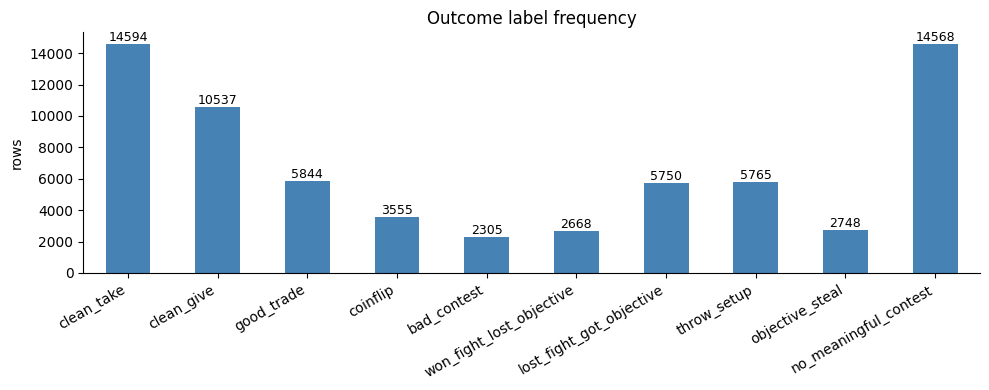

outcome_label
clean_take                  14594
clean_give                  10537
good_trade                   5844
coinflip                     3555
bad_contest                  2305
won_fight_lost_objective     2668
lost_fight_got_objective     5750
throw_setup                  5765
objective_steal              2748
no_meaningful_contest       14568


In [3]:
OUTCOME_ORDER = [
    'clean_take', 'clean_give', 'good_trade', 'coinflip',
    'bad_contest', 'won_fight_lost_objective', 'lost_fight_got_objective',
    'throw_setup', 'objective_steal', 'no_meaningful_contest',
]

counts = df['outcome_label'].value_counts().reindex(OUTCOME_ORDER).dropna()
ax = counts.plot(kind='bar', color='steelblue')
ax.set_title('Outcome label frequency')
ax.set_ylabel('rows')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(counts.to_string())

## 2. Setup profiles

Profiles are **relative** — they compare this team's state to the opponent's at T-30s.

| Profile | Condition | Expected secure rate |
|---|---|---|
| **no_early_setup** | Neither team nearby at T-30 | ~50% (coin flip) |
| **gave_away** | We weren't nearby; enemy was | ~15% |
| **free_setup** | We were nearby; enemy wasn't; no pre-obj deaths | ~90% |
| **free_setup_deaths** | We were nearby; enemy wasn't; had pre-obj deaths | ~80% |
| **clean_contest** | Both nearby; we have no deaths AND equal/more alive | ~70% |
| **disadvantaged** | Both nearby; we had deaths OR fewer alive than enemy | ~40% |

Rules are exclusive and exhaustive — every row gets exactly one label.

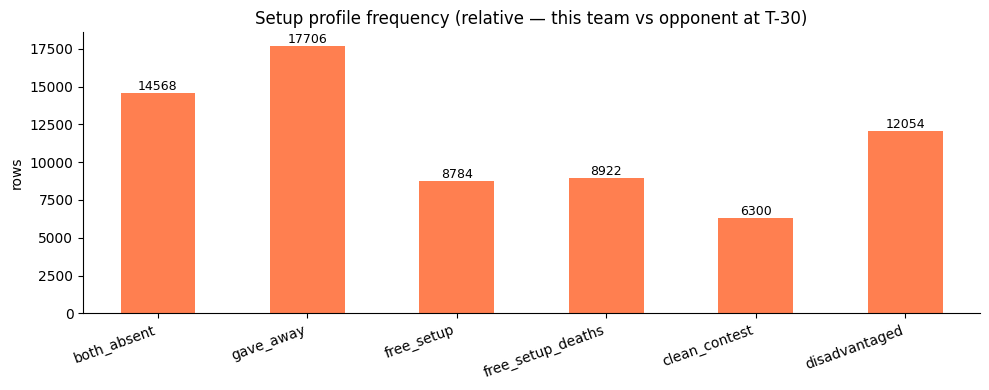

In [4]:
from lolobj.analysis.baseline_report import assign_setup_profiles, PROFILE_ORDER

df['setup_profile'] = assign_setup_profiles(df)

pcounts = df['setup_profile'].value_counts().reindex(PROFILE_ORDER).dropna()

ax = pcounts.plot(kind='bar', color='coral')
ax.set_title('Setup profile frequency (relative — this team vs opponent at T-30)')
ax.set_ylabel('rows')
ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Secure rate by setup profile

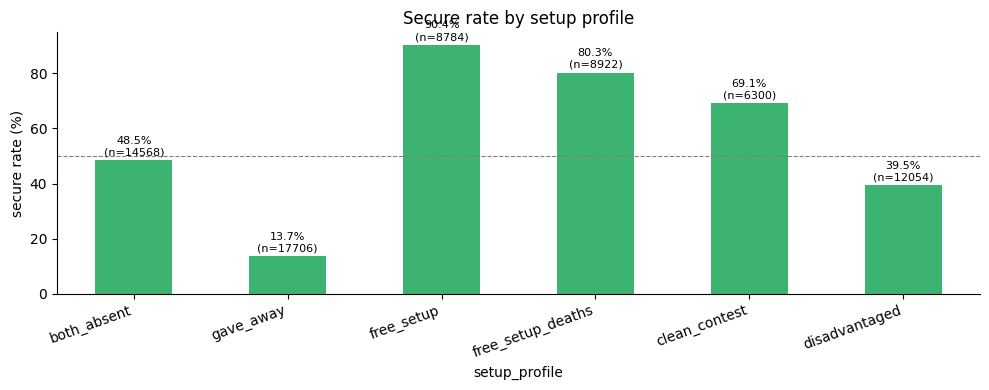

In [5]:
secure_by_profile = (
    df.groupby('setup_profile')['secured']
    .agg(['mean', 'count'])
    .reindex(PROFILE_ORDER)
    .dropna()
    .rename(columns={'mean': 'secure_rate', 'count': 'n'})
)
secure_by_profile['secure_rate_pct'] = (secure_by_profile['secure_rate'] * 100).round(1)

ax = secure_by_profile['secure_rate_pct'].plot(kind='bar', color='mediumseagreen')
ax.set_title('Secure rate by setup profile')
ax.set_ylabel('secure rate (%)')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
plt.xticks(rotation=20, ha='right')
for i, (rate, n) in enumerate(zip(secure_by_profile['secure_rate_pct'], secure_by_profile['n'])):
    ax.annotate(f'{rate}%\n(n={n})', (i, rate + 1), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 3b. Sanity checks — do profiles and outcomes agree?

If the labeling logic is working correctly we should see:
- **free_setup** rows → mostly `clean_take` outcome (high secure rate, near-zero bad_contest)
- **gave_away** rows → mostly `clean_give` or `no_meaningful_contest` (near-zero secure rate)
- **disadvantaged** rows → higher `bad_contest`, `throw_setup`, and `lost_fight_got_objective` rates
- **clean_contest** rows → mixed but centered around 50% (fair fight)
- No outcome leakage: profiles are computed from pre-T features only

Flags to watch: if `free_setup` rows have a low secure rate, or `gave_away` rows somehow frequently secure, something is wrong in feature computation or labeling.

In [6]:
if 'setup_profile' not in df.columns:
    from lolobj.analysis.baseline_report import assign_setup_profiles, PROFILE_ORDER
    df['setup_profile'] = assign_setup_profiles(df)

# Cross-tab: setup_profile x outcome_label (% within each profile)
ct = pd.crosstab(df['setup_profile'], df['outcome_label'], normalize='index') * 100
ct = ct.reindex(index=PROFILE_ORDER, columns=OUTCOME_ORDER).fillna(0).round(1)

print("Outcome distribution within each setup profile (% of rows in that profile):")
print(ct.to_string())

# Secure rate per profile
print("\nSecure rate per profile:")
sr = df.groupby('setup_profile')['secured'].agg(['mean', 'count'])
sr['mean'] = (sr['mean'] * 100).round(1)
print(sr.reindex(PROFILE_ORDER).dropna().rename(columns={'mean': 'secure_%', 'count': 'n'}).to_string())

# Sanity flags
print("\n--- SANITY FLAGS ---")
free_setup_sr  = df[df['setup_profile'] == 'free_setup']['secured'].mean()
gave_away_sr   = df[df['setup_profile'] == 'gave_away']['secured'].mean()
disadv_sr      = df[df['setup_profile'] == 'disadvantaged']['secured'].mean()
contest_sr     = df[df['setup_profile'] == 'clean_contest']['secured'].mean()

print(f"free_setup secure rate    : {free_setup_sr:.1%}  (expect > 85%)")
print(f"gave_away secure rate     : {gave_away_sr:.1%}  (expect < 15%)")
print(f"disadvantaged secure rate : {disadv_sr:.1%}  (expect < 40%)")
print(f"clean_contest secure rate : {contest_sr:.1%}  (expect 55–70%)")

Outcome distribution within each setup profile (% of rows in that profile):
outcome_label      clean_take  clean_give  good_trade  coinflip  bad_contest  won_fight_lost_objective  lost_fight_got_objective  throw_setup  objective_steal  no_meaningful_contest
setup_profile                                                                                                                                                                        
both_absent               0.0         0.0         0.0       0.0          0.0                       0.0                       0.0          0.0              0.0                  100.0
gave_away                 0.0        59.5        26.8       0.0          0.0                       0.0                       0.0          0.0             13.7                    0.0
free_setup               75.7         0.0         1.8       0.0          4.0                       3.8                      14.7          0.0              0.0                    0.0
free_setup_dea

## 3c. Setup matchup results — valid profile pairings

Because profiles are **relative** (this team vs opponent at T-30), most pairings are structurally impossible: if we're classified as `free_setup` (only we're present), the opponent is necessarily `gave_away` (they're absent). The full 6×6 matrix is therefore mostly empty by construction.

The table below shows only the **valid pairings** that can actually co-occur, and the secure rate for the team with "my_profile".

Valid matchup pairings (n >= 20):
       my_profile       opp_profile  secure_pct  count
        gave_away        free_setup         9.0   8784
        gave_away free_setup_deaths        18.4   8922
    disadvantaged     clean_contest        20.5   4190
      both_absent       both_absent        48.5  14568
    disadvantaged     disadvantaged        49.6   7864
    clean_contest     clean_contest        49.8   2110
    clean_contest     disadvantaged        78.8   4190
free_setup_deaths         gave_away        80.3   8922
       free_setup         gave_away        90.4   8784


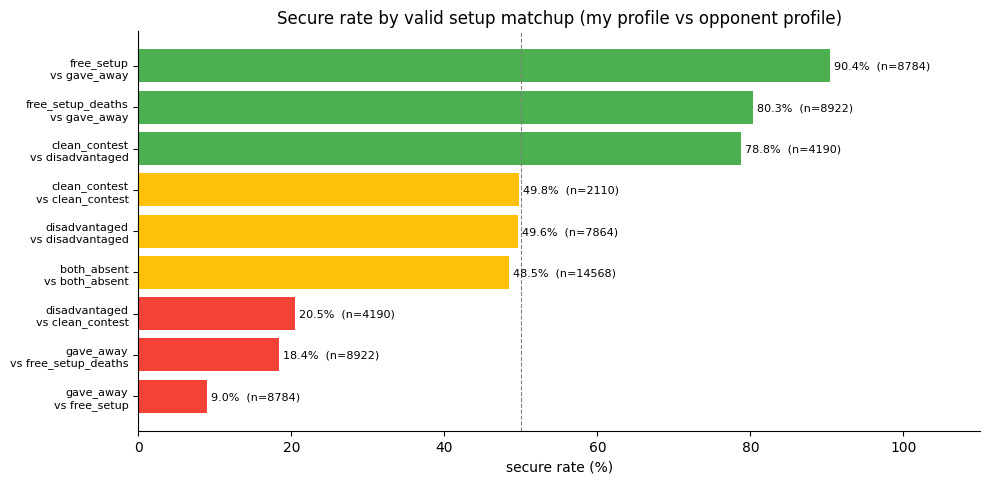

In [7]:
if 'setup_profile' not in df.columns:
    from lolobj.analysis.baseline_report import assign_setup_profiles, PROFILE_ORDER
    df['setup_profile'] = assign_setup_profiles(df)

# Join both teams per objective to get (my_profile, opp_profile) pairs
t100 = df[df['team_id'] == 100][['match_id', 'objective_instance', 'setup_profile', 'secured']].copy()
t200 = df[df['team_id'] == 200][['match_id', 'objective_instance', 'setup_profile', 'secured']].copy()
wide = t100.merge(t200, on=['match_id', 'objective_instance'], suffixes=('_t100', '_t200'))

from_t100 = wide.rename(columns={'setup_profile_t100': 'my_profile',
                                   'setup_profile_t200': 'opp_profile',
                                   'secured_t100': 'secured'})[
    ['match_id', 'objective_instance', 'my_profile', 'opp_profile', 'secured']]
from_t200 = wide.rename(columns={'setup_profile_t200': 'my_profile',
                                   'setup_profile_t100': 'opp_profile',
                                   'secured_t200': 'secured'})[
    ['match_id', 'objective_instance', 'my_profile', 'opp_profile', 'secured']]
matchup = pd.concat([from_t100, from_t200], ignore_index=True)

# Only keep pairings with enough data
agg = matchup.groupby(['my_profile', 'opp_profile'])['secured'].agg(['mean', 'count']).reset_index()
agg = agg[agg['count'] >= 20].copy()
agg['secure_pct'] = (agg['mean'] * 100).round(1)
agg['matchup'] = agg['my_profile'] + '\nvs ' + agg['opp_profile']
agg = agg.sort_values('secure_pct', ascending=True)

print("Valid matchup pairings (n >= 20):")
print(agg[['my_profile', 'opp_profile', 'secure_pct', 'count']].to_string(index=False))

# Horizontal bar chart — colour by secure rate
fig, ax = plt.subplots(figsize=(10, max(4, len(agg) * 0.55)))
colors = ['#F44336' if v < 40 else '#FFC107' if v < 60 else '#4CAF50' for v in agg['secure_pct']]
bars = ax.barh(range(len(agg)), agg['secure_pct'], color=colors)
ax.set_yticks(range(len(agg)))
ax.set_yticklabels(agg['matchup'], fontsize=8)
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('secure rate (%)')
ax.set_title('Secure rate by valid setup matchup (my profile vs opponent profile)')
for i, (val, n) in enumerate(zip(agg['secure_pct'], agg['count'])):
    ax.text(val + 0.5, i, f'{val:.1f}%  (n={n})', va='center', fontsize=8)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

## 4. Key binary feature secure rates

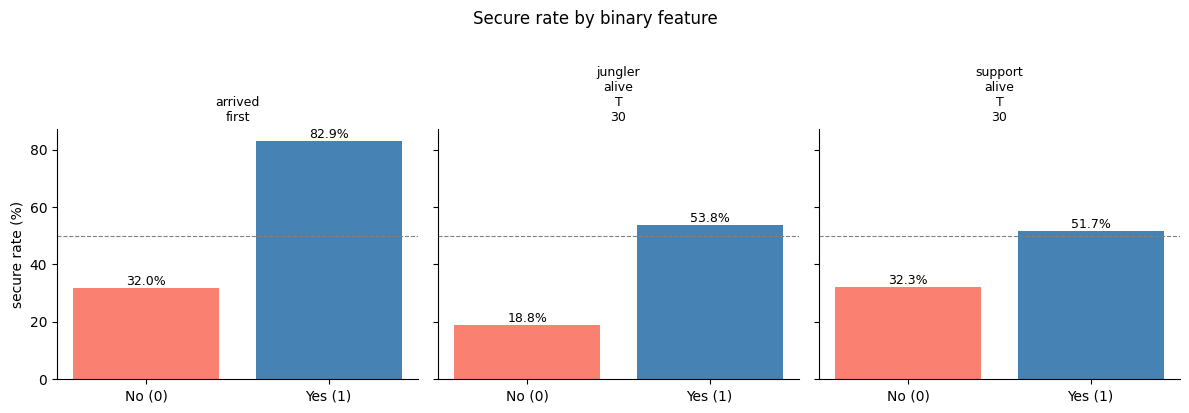

In [8]:
binary_features = [
    'arrived_first',
    'jungler_alive_T_30',
    'support_alive_T_30',
]

fig, axes = plt.subplots(1, len(binary_features), figsize=(12, 4), sharey=True)
for ax, feat in zip(axes, binary_features):
    rates = df.groupby(feat)['secured'].mean() * 100
    bars = ax.bar(['No (0)', 'Yes (1)'], [rates.get(0, 0), rates.get(1, 0)],
                   color=['salmon', 'steelblue'])
    ax.set_title(feat.replace('_', '\n'), fontsize=9)
    ax.set_ylabel('secure rate (%)' if ax == axes[0] else '')
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, [rates.get(0, 0), rates.get(1, 0)]):
        ax.annotate(f'{val:.1f}%', (bar.get_x() + bar.get_width()/2, val + 1),
                    ha='center', fontsize=9)
plt.suptitle('Secure rate by binary feature', y=1.02)
plt.tight_layout()
plt.show()

## 5. Deaths before objective vs secure rate

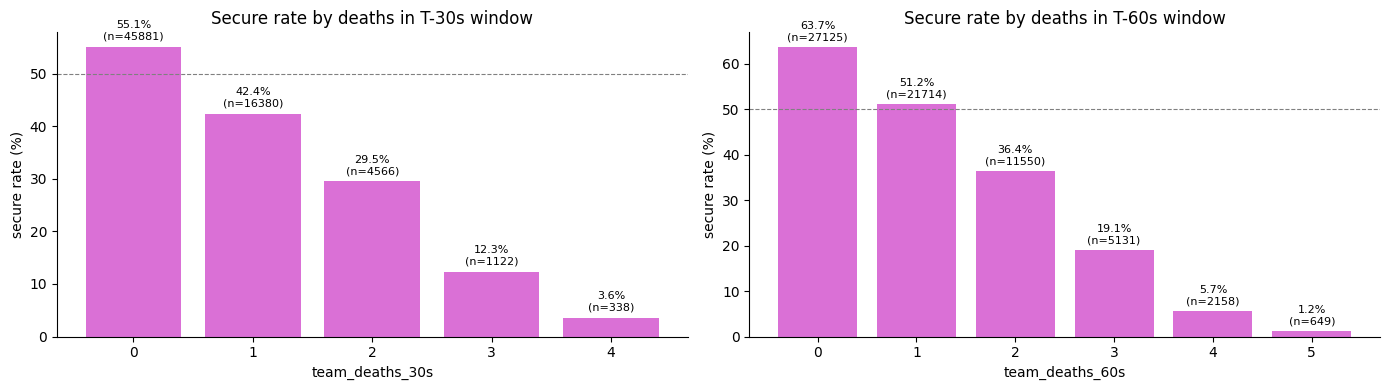


team_deaths_30s:
                 secure_%  count
team_deaths_30s                 
0                    55.1  45881
1                    42.4  16380
2                    29.5   4566
3                    12.3   1122
4                     3.6    338
5                     0.0     47

team_deaths_60s:
                 secure_%  count
team_deaths_60s                 
0                    63.7  27125
1                    51.2  21714
2                    36.4  11550
3                    19.1   5131
4                     5.7   2158
5                     1.2    649
6                     0.0      7

team_deaths_90s:
                 secure_%  count
team_deaths_90s                 
0                    65.9  16421
1                    56.8  20483
2                    46.3  15766
3                    32.6   8977
4                    19.0   4599
5                     7.8   1846
6                     7.3    219
7                     4.8     21
8                    50.0      2


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, col, title in [
    (axes[0], 'team_deaths_30s', 'deaths in T-30s window'),
    (axes[1], 'team_deaths_60s', 'deaths in T-60s window'),
]:
    death_secure = df.groupby(col)['secured'].agg(['mean', 'count'])
    death_secure.columns = ['secure_rate', 'n']
    death_secure = death_secure[death_secure['n'] >= 50]
    death_secure['secure_pct'] = (death_secure['secure_rate'] * 100).round(1)

    ax.bar(death_secure.index.astype(str), death_secure['secure_pct'], color='orchid')
    ax.set_title(f'Secure rate by {title}')
    ax.set_xlabel(col)
    ax.set_ylabel('secure rate (%)')
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
    for i, (rate, n) in enumerate(zip(death_secure['secure_pct'], death_secure['n'])):
        ax.annotate(f'{rate}%\n(n={n})', (i, rate + 1), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print the raw numbers for both windows
for col in ['team_deaths_30s', 'team_deaths_60s', 'team_deaths_90s']:
    rates = df.groupby(col)['secured'].agg(['mean', 'count'])
    rates['mean'] = (rates['mean'] * 100).round(1)
    print(f'\n{col}:')
    print(rates.rename(columns={'mean': 'secure_%'}).to_string())

## 6. Gold diff at T-30 vs secure rate

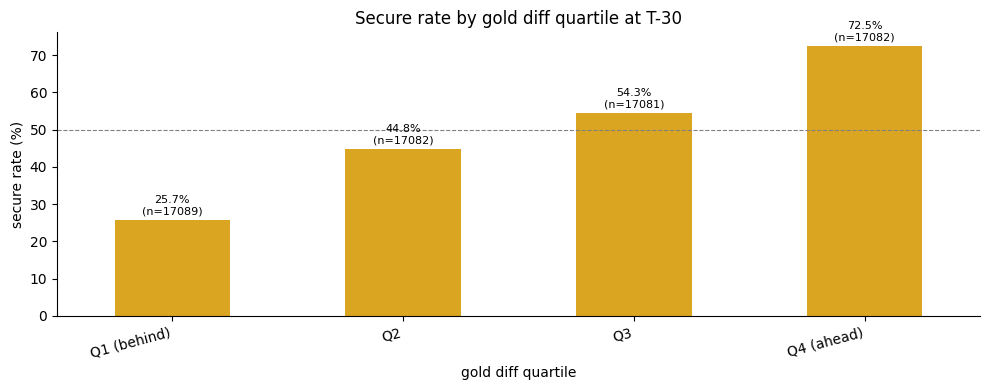

In [10]:
# Bin gold_diff_T_30 into quartiles
df['gold_diff_bin'] = pd.qcut(df['gold_diff_T_30'], q=4,
                               labels=['Q1 (behind)', 'Q2', 'Q3', 'Q4 (ahead)'])
gold_secure = df.groupby('gold_diff_bin', observed=True)['secured'].agg(['mean', 'count'])
gold_secure.columns = ['secure_rate', 'n']

ax = (gold_secure['secure_rate'] * 100).plot(kind='bar', color='goldenrod')
ax.set_title('Secure rate by gold diff quartile at T-30')
ax.set_xlabel('gold diff quartile')
ax.set_ylabel('secure rate (%)')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
plt.xticks(rotation=15, ha='right')
for i, (rate, n) in enumerate(zip(gold_secure['secure_rate'] * 100, gold_secure['n'])):
    ax.annotate(f'{rate:.1f}%\n(n={n})', (i, rate + 1), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 5b. Contest rate by objective type

Not all objectives are genuinely contested. Dragon 1, Dragon 2, and Grubs are frequently taken solo
by the jungler before the enemy team can rotate. For these, a **gave_away** profile is the expected
default, not a failure. Dragon 3+, Baron, and later dragons are more likely to be genuinely contested.

This chart decomposes each objective into four presence buckets at T-30s:
- **contested** = both teams within 2500u
- **free take** = our team present, enemy absent (uncontested setup)
- **gave away** = enemy present, our team absent
- **no early setup** = neither team nearby (objective taken incidentally)


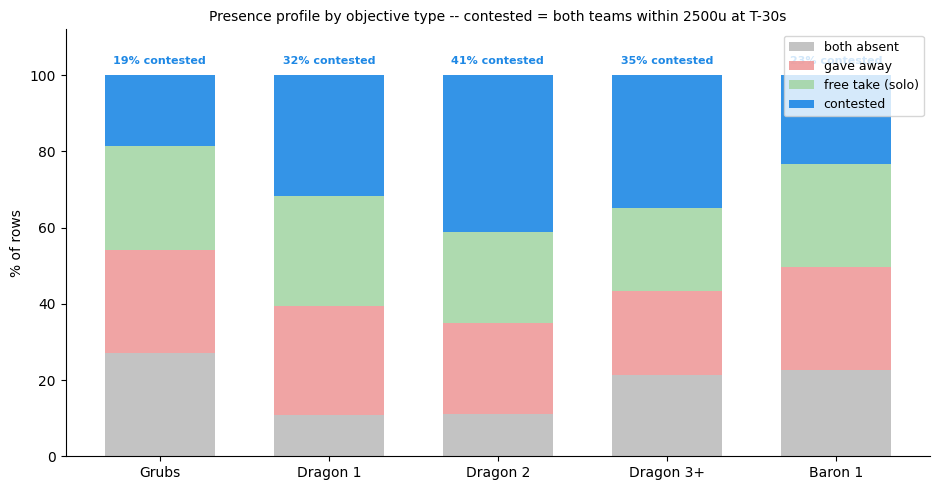


Contest rate by objective:
               n  contested  free_take  gave_away  both_absent
objective                                                     
Grubs      23176       18.6       27.2       27.2         27.0
Dragon 1    7668       31.8       28.7       28.7         10.7
Dragon 2    7450       41.1       23.8       23.8         11.2
Dragon 3+  14916       34.8       21.9       21.9         21.4
Baron 1     5698       23.3       27.0       27.0         22.6

Note: Grubs, Dragon 1, and Dragon 2 have naturally low contest rates.
For these objectives, "gave_away" is often the default, not a mistake.


In [11]:
import numpy as np

_OBJ_LIST_CONTEST = [
    ("Grubs",     df["objective_type"] == "HORDE"),
    ("Dragon 1",  (df["objective_type"] == "DRAGON") & (df["objective_number"] == 1)),
    ("Dragon 2",  (df["objective_type"] == "DRAGON") & (df["objective_number"] == 2)),
    ("Dragon 3+", (df["objective_type"] == "DRAGON") & (df["objective_number"] >= 3)),
    ("Baron 1",   (df["objective_type"] == "BARON_NASHOR") & (df["objective_number"] == 1)),
]

_contest_rows = []
for obj_label, mask in _OBJ_LIST_CONTEST:
    sub = df[mask]
    if len(sub) < 30:
        continue
    n = len(sub)
    n_contested    = ((sub["team_nearby_T_30"] >= 1) & (sub["enemy_nearby_T_30"] >= 1)).sum()
    n_free_take    = ((sub["team_nearby_T_30"] >= 1) & (sub["enemy_nearby_T_30"] == 0)).sum()
    n_gave_away    = ((sub["team_nearby_T_30"] == 0) & (sub["enemy_nearby_T_30"] >= 1)).sum()
    n_no_early_setup  = ((sub["team_nearby_T_30"] == 0) & (sub["enemy_nearby_T_30"] == 0)).sum()
    _contest_rows.append({
        "objective": obj_label, "n": n,
        "contested":   100 * n_contested  / n,
        "free_take":   100 * n_free_take  / n,
        "gave_away":   100 * n_gave_away  / n,
        "no_early_setup": 100 * n_no_early_setup / n,
    })

_cdf = pd.DataFrame(_contest_rows).set_index("objective")
_objs = list(_cdf.index)
_x = np.arange(len(_objs))

fig, ax = plt.subplots(figsize=(max(6, len(_objs) * 1.9), 5))
w = 0.65
b0 = _cdf["no_early_setup"].values
b1 = _cdf["gave_away"].values
b2 = _cdf["free_take"].values
b3 = _cdf["contested"].values

ax.bar(_x, b0,      w, label="no early setup",       color="#bdbdbd", alpha=0.9)
ax.bar(_x, b1,      w, bottom=b0,                 label="gave away",        color="#ef9a9a", alpha=0.9)
ax.bar(_x, b2,      w, bottom=b0+b1,              label="free take (solo)", color="#a5d6a7", alpha=0.9)
ax.bar(_x, b3,      w, bottom=b0+b1+b2,           label="contested",        color="#1e88e5", alpha=0.9)

ax.set_xticks(_x)
ax.set_xticklabels(_objs)
ax.set_ylabel("% of rows")
ax.set_title("Presence profile by objective type -- contested = both teams within 2500u at T-30s", fontsize=10)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 112)

for i, obj in enumerate(_objs):
    pct = _cdf.loc[obj, "contested"]
    ax.annotate(f"{pct:.0f}% contested",
                (_x[i], 103), ha="center", fontsize=8, fontweight="bold", color="#1e88e5")

plt.tight_layout()
plt.show()

print("\nContest rate by objective:")
print(_cdf[["n", "contested", "free_take", "gave_away", "no_early_setup"]].round(1).to_string())
print("\nNote: Grubs, Dragon 1, and Dragon 2 have naturally low contest rates.")
print("For these objectives, \"gave_away\" is often the default, not a mistake.")

## 6b. Gold value of good setup

**Core question:** how much of a gold deficit can good setup overcome?

**Method:** bin `gold_diff_T_30` into fixed-width bins, compute the secure rate per bin per setup profile, then find where each profile's curve crosses 50%. The gap between `free_setup`'s crossing and `disadvantaged`'s crossing is the "gold value" of having clean vs bad setup.

Stratified by objective because later dragons carry larger accumulated combat advantages from dragon buffs. A team 2 000g down at Dragon 1 is in a very different situation than a team 2 000g down at Dragon 3 (soul point).

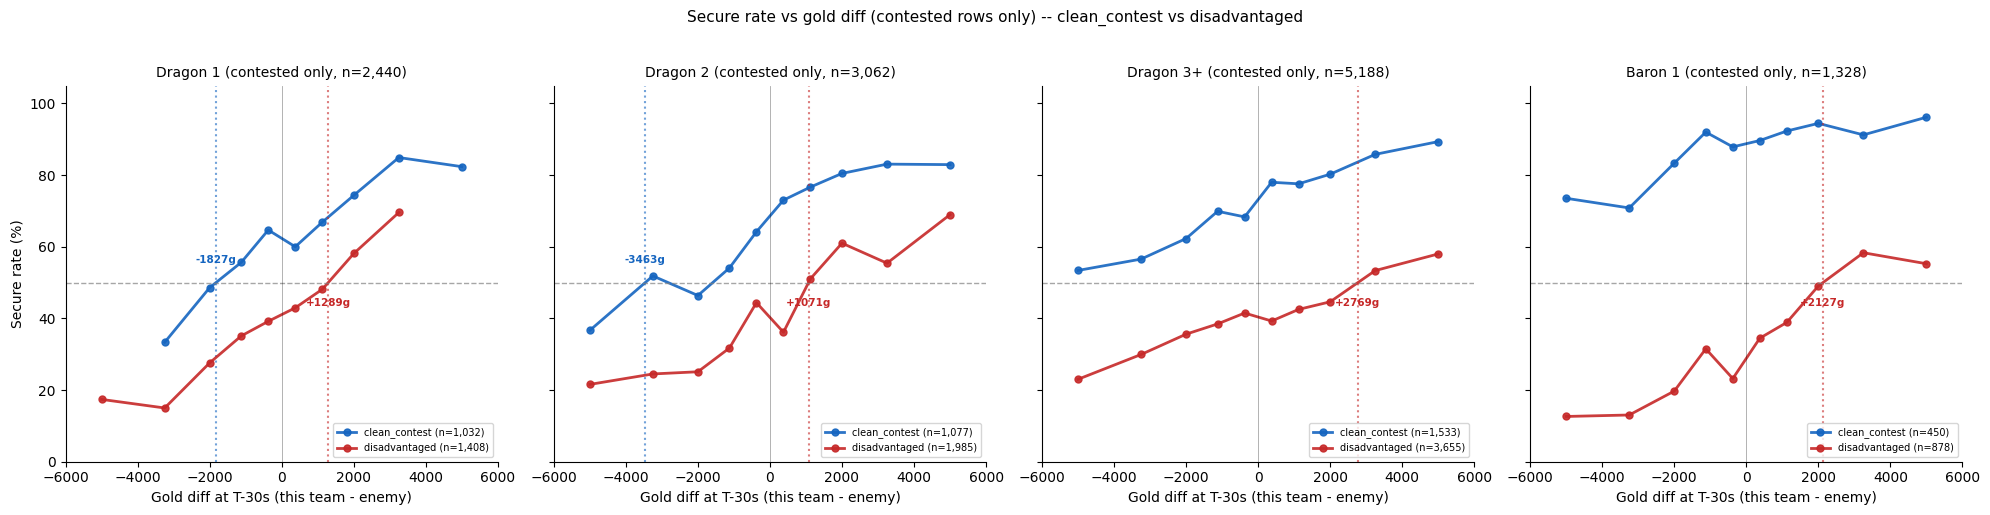

=== 50%-crossing gold values (contested rows only) ===
Negative = team is behind in gold at the coin-flip point.

Objective              clean_contest         disadvantaged
----------------------------------------------------------
Dragon 1                     -1,827g               +1,289g
Dragon 2                     -3,463g               +1,071g
Dragon 3+                no crossing               +2,769g
Baron 1                  no crossing               +2,127g

=== Gold value of clean setup vs disadvantaged (contested rows only) ===
  Dragon 1      : clean_contest @ -1,827g   disadvantaged @ +1,289g   setup ~+3,116g
  Dragon 2      : clean_contest @ -3,463g   disadvantaged @ +1,071g   setup ~+4,534g
  Dragon 3+     : no 50% crossing for ['clean_contest']
  Baron 1       : no 50% crossing for ['clean_contest']


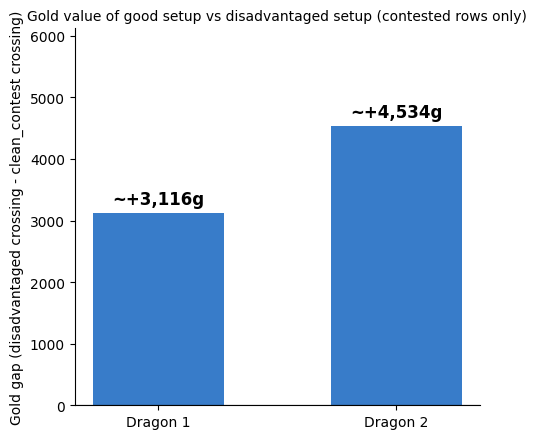

In [12]:
import numpy as np

if "setup_profile" not in df.columns:
    from lolobj.analysis.baseline_report import assign_setup_profiles
    df["setup_profile"] = assign_setup_profiles(df)

# Filter to genuinely contested rows only.
# free_setup / free_setup_deaths have no enemy present so a gold-diff comparison
# is misleading (they secure at high rates regardless of gold because nobody contests).
_contested = df[(df["team_nearby_T_30"] >= 1) & (df["enemy_nearby_T_30"] >= 1)].copy()

SETUP_COLORS = {
    "clean_contest": "#1565c0",
    "disadvantaged": "#c62828",
}
SETUP_PROFILES_PLOT = ["clean_contest", "disadvantaged"]

obj_masks = {
    "Dragon 1":  (_contested["objective_type"] == "DRAGON") & (_contested["objective_number"] == 1),
    "Dragon 2":  (_contested["objective_type"] == "DRAGON") & (_contested["objective_number"] == 2),
    "Dragon 3+": (_contested["objective_type"] == "DRAGON") & (_contested["objective_number"] >= 3),
    "Baron 1":   (_contested["objective_type"] == "BARON_NASHOR") & (_contested["objective_number"] == 1),
}
obj_groups = {k: _contested[m].copy() for k, m in obj_masks.items() if _contested[m].shape[0] >= 100}

GOLD_EDGES = np.array([-6000, -4000, -2500, -1500, -750, 0, 750, 1500, 2500, 4000, 6000])
BIN_MIDS   = (GOLD_EDGES[:-1] + GOLD_EDGES[1:]) / 2
MIN_N      = 15


def _50pct_crossing(gold_mids, rates):
    for i in range(len(rates) - 1):
        r0, r1 = rates[i], rates[i + 1]
        if np.isnan(r0) or np.isnan(r1):
            continue
        if (r0 - 0.5) * (r1 - 0.5) <= 0:
            denom = r1 - r0
            t = (0.5 - r0) / denom if denom else 0.5
            return float(gold_mids[i] + t * (gold_mids[i + 1] - gold_mids[i]))
    return None


n_objs = len(obj_groups)
fig, axes = plt.subplots(1, n_objs, figsize=(5 * n_objs, 5), sharey=True)
if n_objs == 1:
    axes = [axes]

crossing_table = {}

for ax, (obj_label, sub) in zip(axes, obj_groups.items()):
    sub = sub.copy()
    sub["_gbin"] = pd.cut(sub["gold_diff_T_30"], bins=GOLD_EDGES, labels=BIN_MIDS)
    crossings = {}

    for profile in SETUP_PROFILES_PLOT:
        pdata = sub[sub["setup_profile"] == profile]
        if len(pdata) < MIN_N:
            continue
        binned = (pdata.groupby("_gbin", observed=True)["secured"]
                  .agg(["mean", "count"])
                  .rename(columns={"mean": "rate", "count": "n"}))
        binned.loc[binned["n"] < MIN_N, "rate"] = np.nan
        valid = binned.dropna(subset=["rate"])
        if len(valid) < 2:
            continue

        g = np.array(valid.index.astype(float))
        r = valid["rate"].values

        ax.plot(g, r * 100, marker="o",
                label=f"{profile} (n={len(pdata):,})",
                color=SETUP_COLORS.get(profile, "#888"),
                linewidth=2, markersize=5, alpha=0.9)

        cx = _50pct_crossing(g, r)
        if cx is not None:
            crossings[profile] = cx
            ax.axvline(cx, color=SETUP_COLORS.get(profile, "#888"),
                       linestyle=":", linewidth=1.5, alpha=0.6)
            label_y = 55 if list(SETUP_PROFILES_PLOT).index(profile) % 2 == 0 else 43
            ax.annotate(f"{cx:+.0f}g",
                        xy=(cx, label_y),
                        fontsize=7.5, color=SETUP_COLORS.get(profile, "#888"),
                        ha="center", va="bottom", fontweight="bold")

    crossing_table[obj_label] = crossings
    ax.axhline(50, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.axvline(0,  color="black", linewidth=0.6, alpha=0.35)
    ax.set_title(f"{obj_label} (contested only, n={len(sub):,})", fontsize=10)
    ax.set_xlabel("Gold diff at T-30s (this team - enemy)")
    ax.set_xlim(GOLD_EDGES[0], GOLD_EDGES[-1])
    ax.set_ylim(0, 105)
    if ax is axes[0]:
        ax.set_ylabel("Secure rate (%)")
    ax.legend(fontsize=7, loc="lower right")

plt.suptitle(
    "Secure rate vs gold diff (contested rows only) -- clean_contest vs disadvantaged",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

print("=== 50%-crossing gold values (contested rows only) ===")
print("Negative = team is behind in gold at the coin-flip point.\n")
col_w = 20
print(f'{"Objective":<14}', end="")
for p in SETUP_PROFILES_PLOT:
    print(f"  {p:>{col_w}}", end="")
print()
print("-" * (14 + len(SETUP_PROFILES_PLOT) * (col_w + 2)))
for obj_label, cx in crossing_table.items():
    print(f"{obj_label:<14}", end="")
    for p in SETUP_PROFILES_PLOT:
        val = cx.get(p)
        txt = f"{val:+,.0f}g" if val is not None else "no crossing"
        print(f"  {txt:>{col_w}}", end="")
    print()

gold_values = {}
for obj_label, cx in crossing_table.items():
    cc  = cx.get("clean_contest")
    dis = cx.get("disadvantaged")
    if cc is not None and dis is not None:
        gold_values[obj_label] = dis - cc

print("\n=== Gold value of clean setup vs disadvantaged (contested rows only) ===")
for obj_label in obj_groups:
    cx = crossing_table.get(obj_label, {})
    cc  = cx.get("clean_contest")
    dis = cx.get("disadvantaged")
    if cc is not None and dis is not None:
        gv = dis - cc
        print(f"  {obj_label:<14}: clean_contest @ {cc:+,.0f}g   disadvantaged @ {dis:+,.0f}g   setup ~{gv:+,.0f}g")
    else:
        missing = [p for p in ("clean_contest", "disadvantaged") if cx.get(p) is None]
        print(f"  {obj_label:<14}: no 50% crossing for {missing}")

if gold_values:
    fig, ax = plt.subplots(figsize=(max(5, len(gold_values) * 2), 4.5))
    labels = list(gold_values.keys())
    vals   = [gold_values[k] for k in labels]
    bars   = ax.bar(labels, vals, color="#1565c0", alpha=0.85, width=0.55)
    for bar, val in zip(bars, vals):
        ax.annotate(f"~{val:+,.0f}g",
                    (bar.get_x() + bar.get_width() / 2, val + 80),
                    ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Gold gap (disadvantaged crossing - clean_contest crossing)")
    ax.set_title(
        "Gold value of good setup vs disadvantaged setup (contested rows only)",
        fontsize=10,
    )
    ax.set_ylim(0, max(vals) * 1.35 if vals else 3000)
    plt.tight_layout()
    plt.show()

## 7. Feature correlation with `secured`

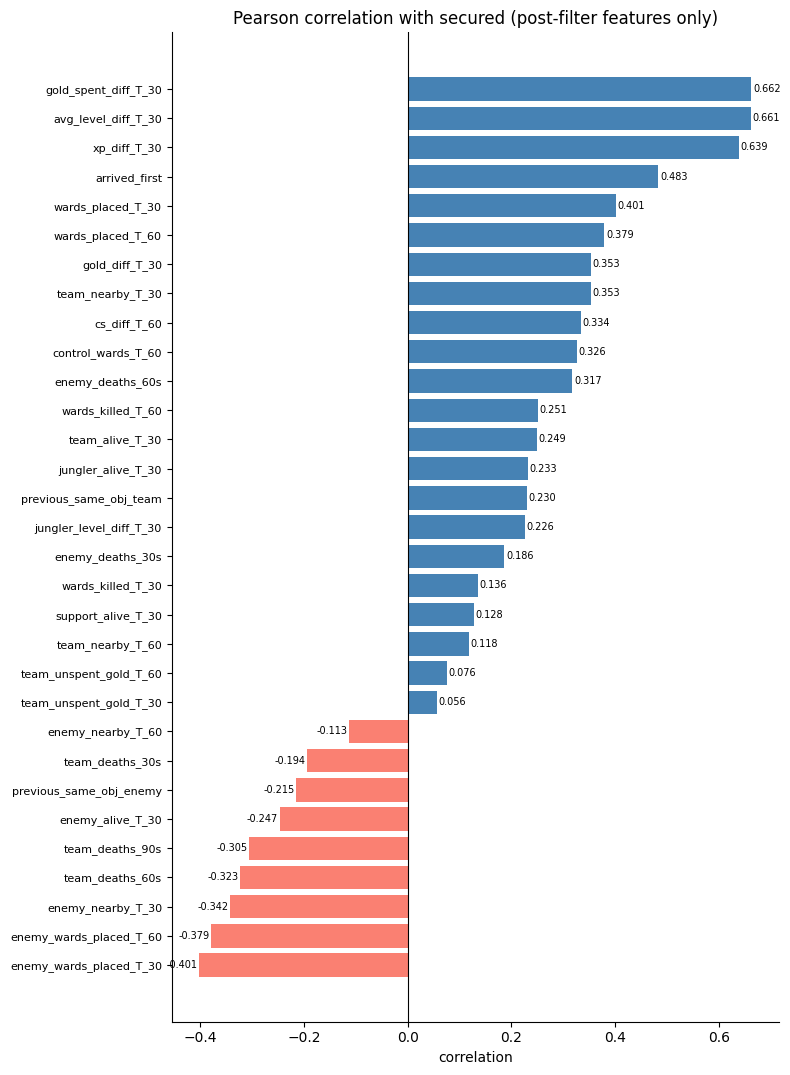

enemy_wards_placed_T_30   -0.401
enemy_wards_placed_T_60   -0.379
enemy_nearby_T_30         -0.342
team_deaths_60s           -0.323
team_deaths_90s           -0.305
enemy_alive_T_30          -0.247
previous_same_obj_enemy   -0.215
team_deaths_30s           -0.194
enemy_nearby_T_60         -0.113
team_unspent_gold_T_30     0.056
team_unspent_gold_T_60     0.076
team_nearby_T_60           0.118
support_alive_T_30         0.128
wards_killed_T_30          0.136
enemy_deaths_30s           0.186
jungler_level_diff_T_30    0.226
previous_same_obj_team     0.230
jungler_alive_T_30         0.233
team_alive_T_30            0.249
wards_killed_T_60          0.251
enemy_deaths_60s           0.317
control_wards_T_60         0.326
cs_diff_T_60               0.334
team_nearby_T_30           0.353
gold_diff_T_30             0.353
wards_placed_T_60          0.379
wards_placed_T_30          0.401
arrived_first              0.483
xp_diff_T_30               0.639
avg_level_diff_T_30        0.661
gold_spent

In [13]:
# Uses FEATURES_KEEP from the feature-filtering cell — weak-signal and
# redundant sibling features are excluded before this chart is drawn.
corr = df[FEATURES_KEEP + ['secured']].corr()['secured'].drop('secured').sort_values()

colors = ['salmon' if v < 0 else 'steelblue' for v in corr]
fig, ax = plt.subplots(figsize=(8, max(6, len(corr) * 0.35)))
ax.barh(range(len(corr)), corr.values, color=colors)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.index, fontsize=8)
ax.set_title('Pearson correlation with secured (post-filter features only)')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('correlation')
for i, val in enumerate(corr.values):
    ax.annotate(f'{val:.3f}', (val + (0.003 if val >= 0 else -0.003), i),
                va='center', ha='left' if val >= 0 else 'right', fontsize=7)
plt.tight_layout()
plt.show()

print(corr.round(3).to_string())

## 7b. Feature-feature correlation heatmap

Shows how all numeric features correlate with each other and with `secured`. Useful for spotting redundant features and natural clusters (e.g. T_30 vs T_60 versions of the same stat).

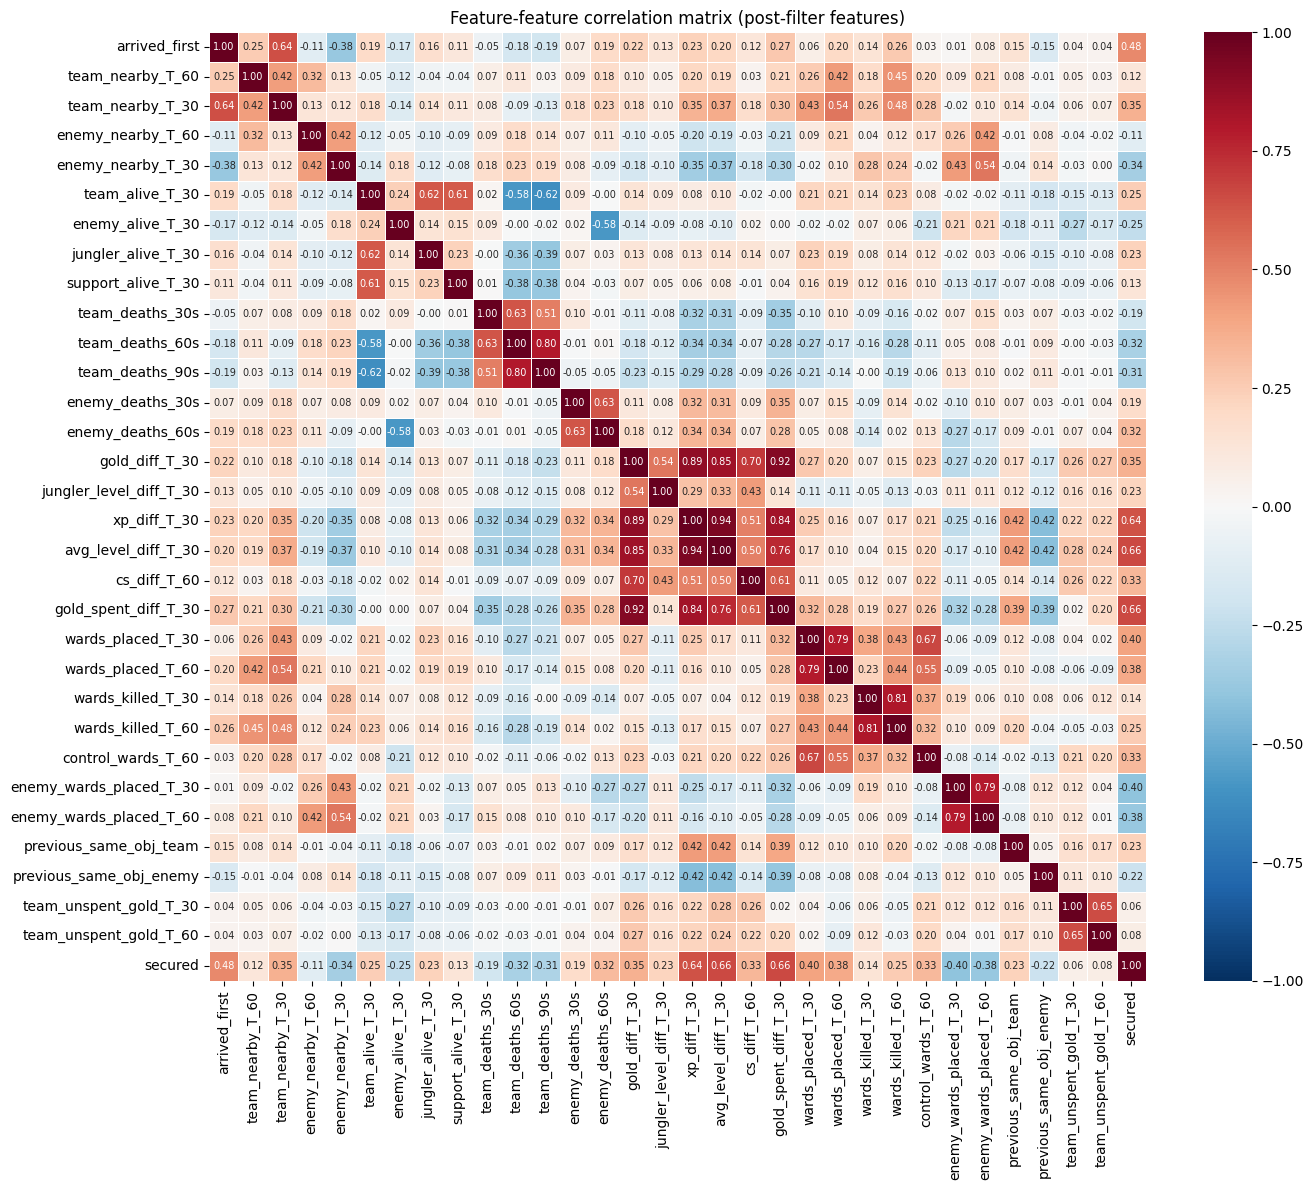

In [14]:
try:
    import seaborn as sns
    has_seaborn = True
except ImportError:
    has_seaborn = False
    print('seaborn not installed — falling back to matplotlib. pip install seaborn for a nicer heatmap.')

# Use the post-filter feature set so the matrix only shows informative features.
heatmap_features = FEATURES_KEEP + ['secured']
corr_matrix = df[heatmap_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))

if has_seaborn:
    sns.heatmap(
        corr_matrix,
        annot=True, fmt='.2f', annot_kws={'size': 7},
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        linewidths=0.4, ax=ax,
    )
else:
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(heatmap_features)))
    ax.set_yticks(range(len(heatmap_features)))
    ax.set_xticklabels(heatmap_features, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(heatmap_features, fontsize=7)
    for i in range(len(heatmap_features)):
        for j in range(len(heatmap_features)):
            ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}',
                    ha='center', va='center', fontsize=5.5)

ax.set_title('Feature-feature correlation matrix (post-filter features)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Dragon 1 vs Dragon 2 — outcome composition

> **Note on secure rates**: across all rows the aggregate secure rate is always ~50% by construction — for every objective one team secures it, the other doesn't. Comparing objective types by secure rate is therefore uninformative. The interesting comparison is *how* objectives are contested: clean takes, throw-setups, coinflips, etc.

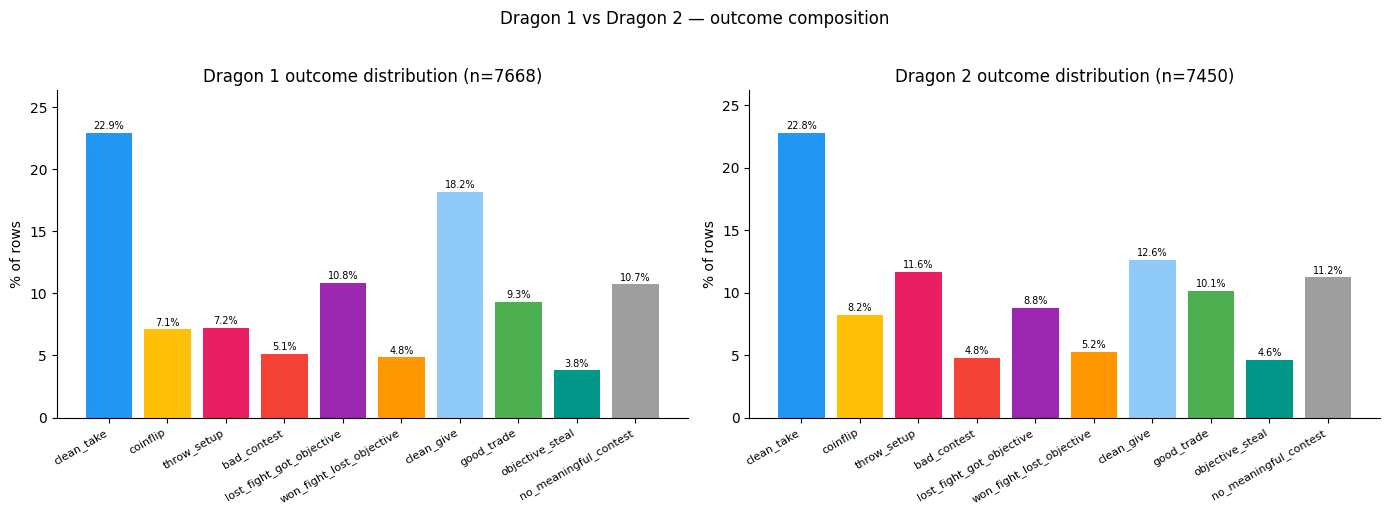

Metric                                Dragon 1   Dragon 2
---------------------------------------------------------
arrived_first %                          38.51      37.14
avg deaths in T-60s                       0.89       1.13
avg deaths in T-30s                       0.35       0.48
throw_setup rate %                        7.20      11.64
bad_contest rate %                        5.14       4.77
clean_take rate %                        22.91      22.77
coinflip rate %                           7.11       8.20
no_meaningful_contest %                  10.72      11.22
avg jungler alive T-30                    0.95       0.90
avg support alive T-30                    0.93       0.88


In [15]:
dragons = df[df['objective_type'] == 'DRAGON']

# Outcome composition stacked bars
OUTCOME_COLORS = {
    'clean_take':                '#2196F3',
    'clean_give':                '#90CAF9',
    'good_trade':                '#4CAF50',
    'coinflip':                  '#FFC107',
    'bad_contest':               '#F44336',
    'won_fight_lost_objective':  '#FF9800',
    'lost_fight_got_objective':  '#9C27B0',
    'throw_setup':               '#E91E63',
    'objective_steal':           '#009688',
    'no_meaningful_contest':     '#9E9E9E',
}

labels_to_show = [
    'clean_take', 'coinflip', 'throw_setup', 'bad_contest',
    'lost_fight_got_objective', 'won_fight_lost_objective',
    'clean_give', 'good_trade', 'objective_steal', 'no_meaningful_contest',
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dragon_num in zip(axes, [1, 2]):
    sub = dragons[dragons['objective_number'] == dragon_num]
    comp = sub['outcome_label'].value_counts(normalize=True) * 100
    comp = comp.reindex(labels_to_show).fillna(0)
    ax.bar(comp.index, comp.values,
           color=[OUTCOME_COLORS.get(l, '#ccc') for l in comp.index])
    ax.set_title(f'Dragon {dragon_num} outcome distribution (n={len(sub)})')
    ax.set_ylabel('% of rows')
    ax.set_ylim(0, comp.max() * 1.15)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    for i, (lbl, val) in enumerate(zip(comp.index, comp.values)):
        if val > 1:
            ax.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=7)

plt.suptitle('Dragon 1 vs Dragon 2 — outcome composition', y=1.02)
plt.tight_layout()
plt.show()

# Summary stats that ARE meaningful (not secure rate)
print(f'{"Metric":<35} {"Dragon 1":>10} {"Dragon 2":>10}')
print('-' * 57)
for num in [1, 2]:
    sub = dragons[dragons['objective_number'] == num]
for metric, col, fn in [
    ('arrived_first %',            'arrived_first',          lambda s: s.mean() * 100),
    ('avg deaths in T-60s',        'team_deaths_60s',        lambda s: s.mean()),
    ('avg deaths in T-30s',        'team_deaths_30s',        lambda s: s.mean()),
    ('throw_setup rate %',         'outcome_label',          lambda s: (s=='throw_setup').mean()*100),
    ('bad_contest rate %',         'outcome_label',          lambda s: (s=='bad_contest').mean()*100),
    ('clean_take rate %',          'outcome_label',          lambda s: (s=='clean_take').mean()*100),
    ('coinflip rate %',            'outcome_label',          lambda s: (s=='coinflip').mean()*100),
    ('no_meaningful_contest %',    'outcome_label',          lambda s: (s=='no_meaningful_contest').mean()*100),
    ('avg jungler alive T-30',     'jungler_alive_T_30',     lambda s: s.mean()),
    ('avg support alive T-30',     'support_alive_T_30',     lambda s: s.mean()),
]:
    d1 = fn(dragons[dragons['objective_number'] == 1][col])
    d2 = fn(dragons[dragons['objective_number'] == 2][col])
    print(f'{metric:<35} {d1:>10.2f} {d2:>10.2f}')

## 8b. Dragon 3, 4, 5+ comparison

Later dragons are higher stakes — dragon 4 awards soul, dragon 5+ can be soul/elder chasing. Expect throw_setup and bad_contest rates to rise as teams are more willing to force fights.

            n_rows  clean_take_%  coinflip_%  throw_%  bad_contest_%  no_contest_%  avg_deaths_30s  avg_deaths_60s  arrived_first_%
dragon_num                                                                                                                         
1             7668          22.9         7.1      7.2            5.1          10.7            0.35            0.89             38.5
2             7450          22.8         8.2     11.6            4.8          11.2            0.48            1.13             37.1
3             6742          23.8         6.2     12.3            3.4          17.2            0.55            1.24             35.3
4             5202          23.4         4.5     11.9            3.0          23.6            0.58            1.29             33.8
5             2248          22.7         3.8     12.0            2.5          26.4            0.59            1.24             32.3
6              618          21.2         3.1     11.8            2.8        

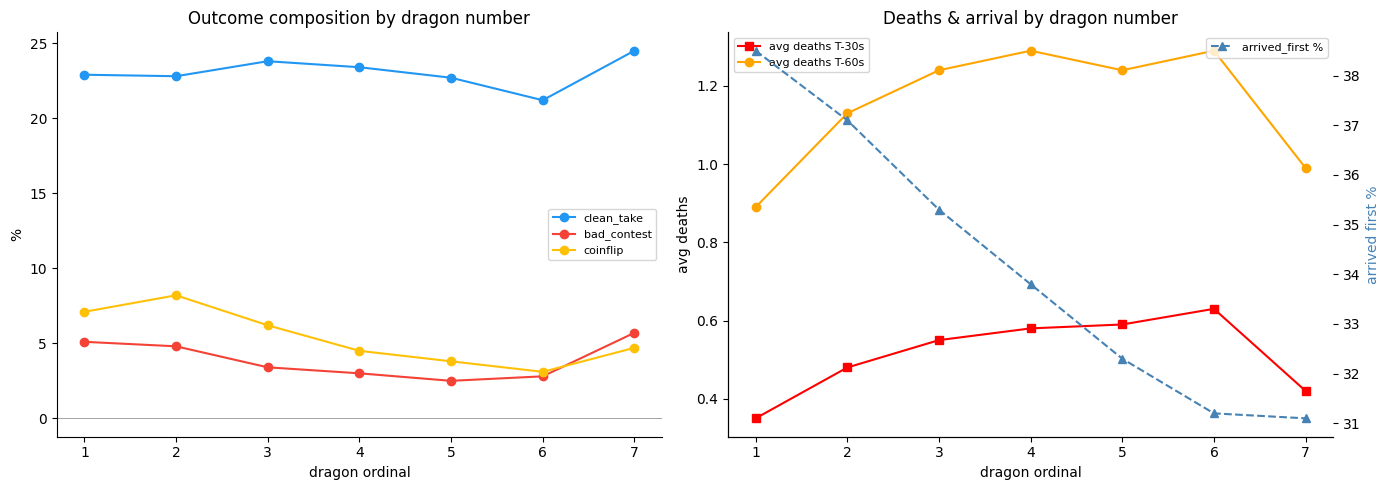

In [16]:
dragons_all = df[df['objective_type'] == 'DRAGON'].copy()
dragon_nums = sorted(dragons_all['objective_number'].unique())

summary = []
for num in dragon_nums:
    sub = dragons_all[dragons_all['objective_number'] == num]
    summary.append({
        'dragon_num': num,
        'n_rows': len(sub),
        'clean_take_%': round((sub['outcome_label'] == 'clean_take').mean() * 100, 1),
        'coinflip_%':   round((sub['outcome_label'] == 'coinflip').mean() * 100, 1),
        'throw_%':      round((sub['outcome_label'] == 'throw_setup').mean() * 100, 1),
        'bad_contest_%':round((sub['outcome_label'] == 'bad_contest').mean() * 100, 1),
        'no_contest_%': round((sub['outcome_label'] == 'no_meaningful_contest').mean() * 100, 1),
        'avg_deaths_30s':   round(sub['team_deaths_30s'].mean(), 2),
        'avg_deaths_60s':   round(sub['team_deaths_60s'].mean(), 2),
        'arrived_first_%':  round(sub['arrived_first'].mean() * 100, 1),
    })

summary_df = pd.DataFrame(summary).set_index('dragon_num')
print(summary_df.to_string())

# Outcome composition progression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

key_outcomes = ['clean_take', 'throw_setup', 'bad_contest', 'coinflip', 'no_meaningful_contest']
colors_map = {'clean_take': '#2196F3', 'throw_setup': '#E91E63',
              'bad_contest': '#F44336', 'coinflip': '#FFC107', 'no_meaningful_contest': '#9E9E9E'}

ax = axes[0]
for outcome in key_outcomes:
    col = f'{outcome}_%'
    if col in summary_df.columns:
        ax.plot(summary_df.index, summary_df[col], marker='o', label=outcome,
                color=colors_map.get(outcome))
ax.set_title('Outcome composition by dragon number')
ax.set_xlabel('dragon ordinal')
ax.set_ylabel('%')
ax.set_xticks(dragon_nums)
ax.legend(fontsize=8)
ax.axhline(0, color='gray', linewidth=0.5)

# Deaths & arrival progression
ax = axes[1]
ax.plot(summary_df.index, summary_df['avg_deaths_30s'], marker='s', color='red', label='avg deaths T-30s')
ax.plot(summary_df.index, summary_df['avg_deaths_60s'], marker='o', color='orange', label='avg deaths T-60s')
ax2 = ax.twinx()
ax2.plot(summary_df.index, summary_df['arrived_first_%'], marker='^', color='steelblue',
         linestyle='--', label='arrived_first %')
ax2.set_ylabel('arrived first %', color='steelblue')
ax.set_title('Deaths & arrival by dragon number')
ax.set_xlabel('dragon ordinal')
ax.set_ylabel('avg deaths')
ax.set_xticks(dragon_nums)
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 9. Grubs, Herald, and Baron

- **Voidgrubs (HORDE)**: 6 grubs total, first camp spawns ~5 min. Ordinals 1-3 = first camp, 4-6 = second camp. Most games only see the first camp fully taken.
- **Riftherald (RIFTHERALD)**: Spawns ~8 min, only one per game before Baron replaces it. High-value tempo tool.
- **Baron Nashor (BARON_NASHOR)**: Spawns at 20 min, major power spike. Later barons are riskier to contest.

Note: outcome labels (clean_take, coinflip, etc.) apply to all objective types, but the thresholds in the classifier were tuned for dragon. Results for other objectives may show edge cases.

                     n  clean_take_%  coinflip_%  throw_%  bad_contest_%  no_contest_%  avg_jg_alive_T30  avg_deaths_30s  avg_deaths_60s  arrived_first_%
objective                                                                                                                                                
Voidgrubs (1-3)  22978          18.1         4.9      6.1            3.0          27.1              0.96            0.41            0.90             31.0
Voidgrubs (4-6)    198          18.2         3.0      8.1            2.5          19.2              0.95            0.39            0.92             37.9
Riftherald        7174          20.2         4.3      7.1            2.5          19.9              0.88            0.46            1.08             35.3
Baron 1           5698          26.2         2.9      8.2            2.9          22.6              0.75            0.37            1.27             36.1
Baron 2           1910          23.3         2.0      6.9            2.6    

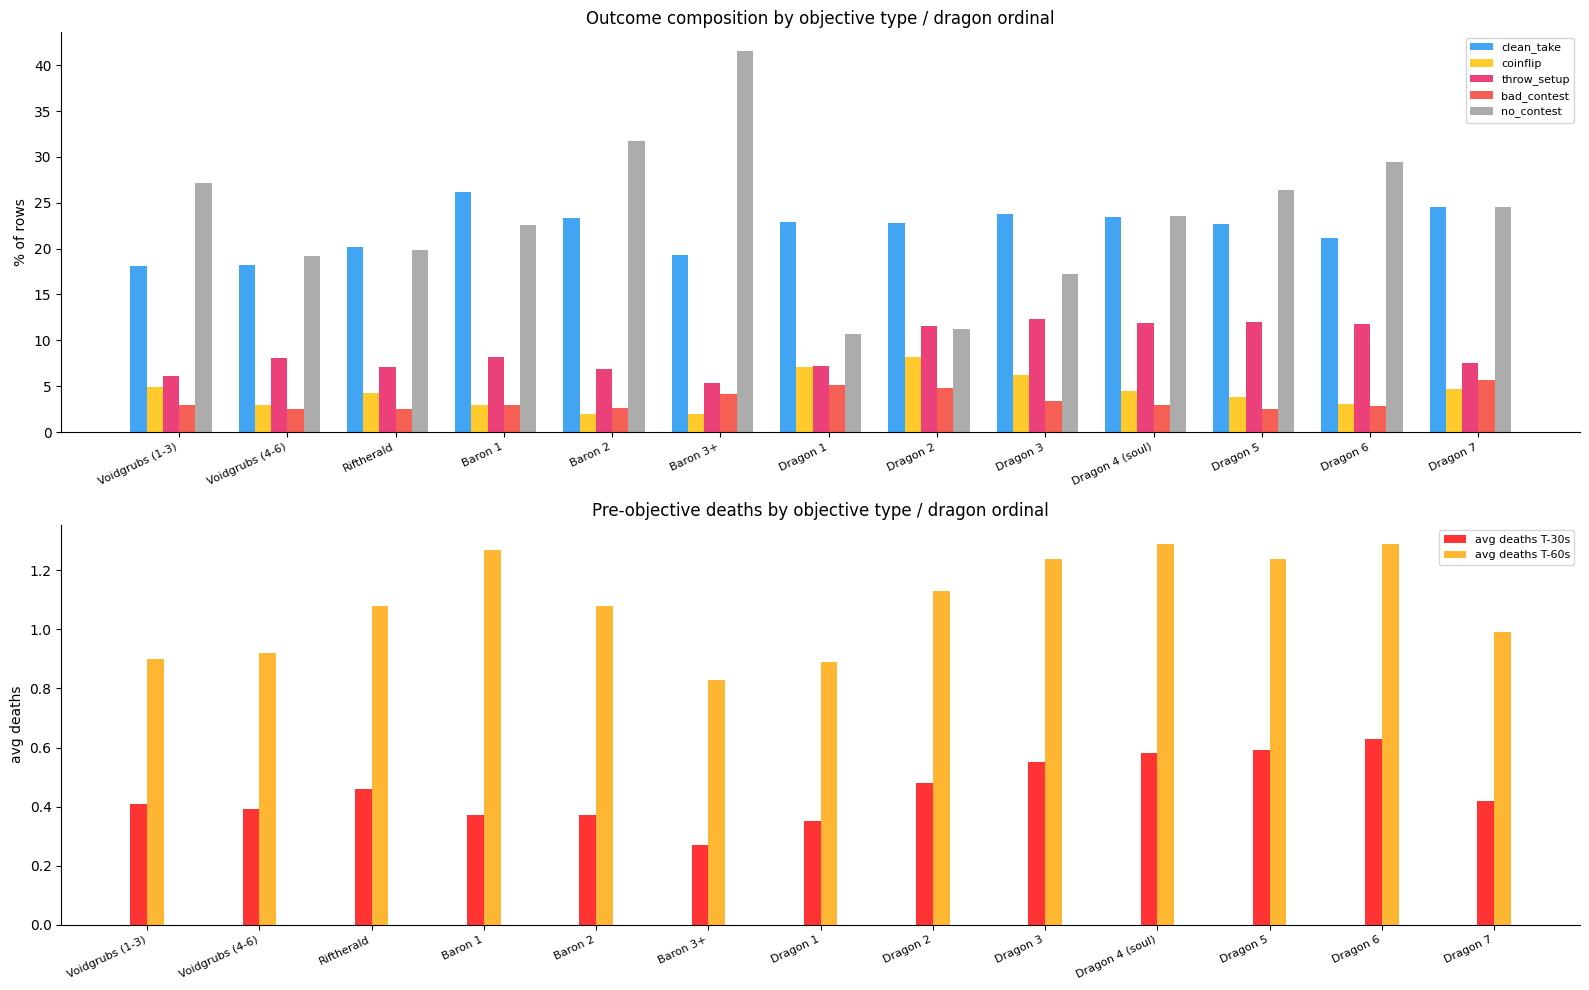

In [17]:
obj_groups = {}

# Voidgrubs, Herald, Baron
obj_groups['Voidgrubs (1-3)'] = df[(df['objective_type'] == 'HORDE') & (df['objective_number'] <= 3)]
obj_groups['Voidgrubs (4-6)'] = df[(df['objective_type'] == 'HORDE') & (df['objective_number'] >= 4)]
obj_groups['Riftherald']      = df[df['objective_type'] == 'RIFTHERALD']
obj_groups['Baron 1']         = df[(df['objective_type'] == 'BARON_NASHOR') & (df['objective_number'] == 1)]
obj_groups['Baron 2']         = df[(df['objective_type'] == 'BARON_NASHOR') & (df['objective_number'] == 2)]
obj_groups['Baron 3+']        = df[(df['objective_type'] == 'BARON_NASHOR') & (df['objective_number'] >= 3)]

# Dragons by ordinal 1-7 (each ordinal = a distinct game-state; not all games reach each number)
dragon_ordinal_labels = {1: 'Dragon 1', 2: 'Dragon 2', 3: 'Dragon 3',
                          4: 'Dragon 4 (soul)', 5: 'Dragon 5', 6: 'Dragon 6', 7: 'Dragon 7'}
for ordinal, label in dragon_ordinal_labels.items():
    sub = df[(df['objective_type'] == 'DRAGON') & (df['objective_number'] == ordinal)]
    if len(sub) >= 50:
        obj_groups[label] = sub

rows = []
for label, sub in obj_groups.items():
    if len(sub) == 0:
        continue
    rows.append({
        'objective': label,
        'n': len(sub),
        'clean_take_%':   round((sub['outcome_label'] == 'clean_take').mean() * 100, 1),
        'coinflip_%':     round((sub['outcome_label'] == 'coinflip').mean() * 100, 1),
        'throw_%':        round((sub['outcome_label'] == 'throw_setup').mean() * 100, 1),
        'bad_contest_%':  round((sub['outcome_label'] == 'bad_contest').mean() * 100, 1),
        'no_contest_%':   round((sub['outcome_label'] == 'no_meaningful_contest').mean() * 100, 1),
        'avg_jg_alive_T30':  round(sub['jungler_alive_T_30'].mean(), 2),
        'avg_deaths_30s':    round(sub['team_deaths_30s'].mean(), 2),
        'avg_deaths_60s':    round(sub['team_deaths_60s'].mean(), 2),
        'arrived_first_%':   round(sub['arrived_first'].mean() * 100, 1),
    })

comparison = pd.DataFrame(rows).set_index('objective')
print(comparison.to_string())

# Outcome composition grouped bar chart
x = range(len(comparison))
width = 0.15
outcomes_to_plot = ['clean_take_%', 'coinflip_%', 'throw_%', 'bad_contest_%', 'no_contest_%']
outcome_labels_short = ['clean_take', 'coinflip', 'throw_setup', 'bad_contest', 'no_contest']
palette = ['#2196F3', '#FFC107', '#E91E63', '#F44336', '#9E9E9E']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax = axes[0]
for i, (col, lbl, color) in enumerate(zip(outcomes_to_plot, outcome_labels_short, palette)):
    offset = (i - len(outcomes_to_plot) / 2) * width
    ax.bar([xi + offset for xi in x], comparison[col], width, label=lbl, color=color, alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(comparison.index, rotation=25, ha='right', fontsize=8)
ax.set_title('Outcome composition by objective type / dragon ordinal')
ax.set_ylabel('% of rows')
ax.legend(fontsize=8)

# Deaths & arrival
ax = axes[1]
ax.bar([xi - width/2 for xi in x], comparison['avg_deaths_30s'], width, label='avg deaths T-30s', color='red', alpha=0.8)
ax.bar([xi + width/2 for xi in x], comparison['avg_deaths_60s'], width, label='avg deaths T-60s', color='orange', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(comparison.index, rotation=25, ha='right', fontsize=8)
ax.set_title('Pre-objective deaths by objective type / dragon ordinal')
ax.set_ylabel('avg deaths')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Rank breakdown

Rank distribution:
rank_bucket
mid        20856
high       17524
low        16892
elite      12244
unknown      818

98.8% of rows have known rank


C:\Users\Laser\AppData\Local\Temp\ipykernel_133764\3373700560.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ct_rate = df[df['rank_bucket'].isin(ranks_present)].groupby('rank_bucket').apply(
C:\Users\Laser\AppData\Local\Temp\ipykernel_133764\3373700560.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  throw_rate = df[df['rank_bucket'].isin(ranks_present)].groupby('rank_bucket').apply(
C:\Users\Laser\AppData\

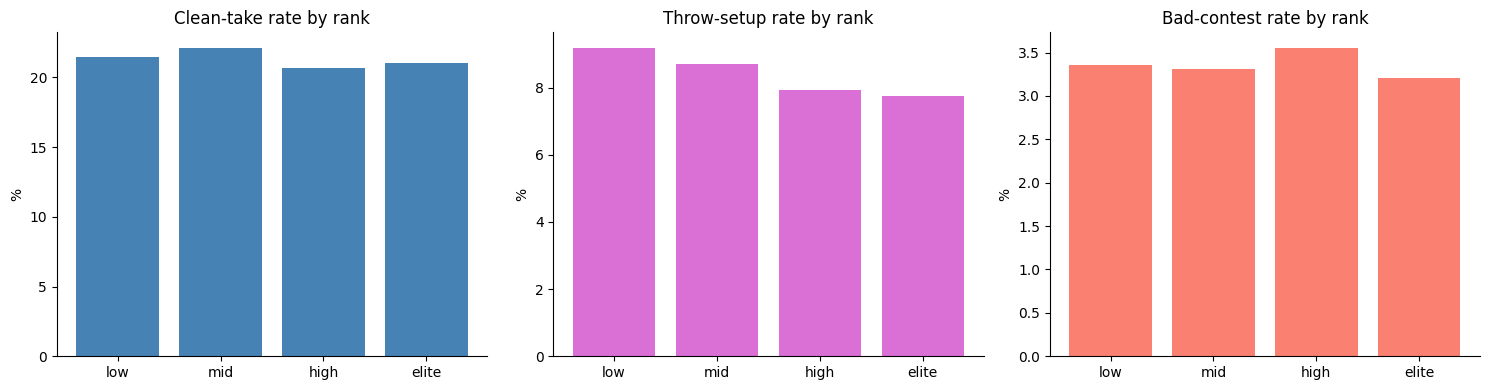


Outcome composition by rank (% of rows):
outcome_label  clean_take  clean_give  good_trade  coinflip  bad_contest  won_fight_lost_objective  lost_fight_got_objective  throw_setup  objective_steal  no_meaningful_contest
rank_bucket                                                                                                                                                                      
low                  21.4        15.3         8.5       5.4          3.4                       4.1                       8.7          9.2              4.1                   19.8
mid                  22.1        15.8         8.2       5.0          3.3                       4.0                       8.3          8.7              4.0                   20.6
high                 20.6        15.0         8.8       5.4          3.6                       3.9                       8.5          7.9              4.1                   22.2
elite                21.0        15.5         8.8       5.1         

In [18]:
rank_counts = df['rank_bucket'].value_counts()
print('Rank distribution:')
print(rank_counts.to_string())
print(f"\n{100 * (df['rank_bucket'] != 'unknown').mean():.1f}% of rows have known rank")

rank_order = ['low', 'mid', 'high', 'elite']
ranks_present = [r for r in rank_order if r in df['rank_bucket'].values]

if ranks_present:
    # Outcome composition by rank — meaningful; aggregate secure rate is always ~50%
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # clean_take rate by rank (how often did the team set up cleanly?)
    ct_rate = df[df['rank_bucket'].isin(ranks_present)].groupby('rank_bucket').apply(
        lambda x: (x['outcome_label'] == 'clean_take').mean() * 100
    )
    axes[0].bar(rank_order, [ct_rate.get(r, 0) for r in rank_order], color='steelblue')
    axes[0].set_title('Clean-take rate by rank')
    axes[0].set_ylabel('%')

    # Throw setup rate by rank
    throw_rate = df[df['rank_bucket'].isin(ranks_present)].groupby('rank_bucket').apply(
        lambda x: (x['outcome_label'] == 'throw_setup').mean() * 100
    )
    axes[1].bar(rank_order, [throw_rate.get(r, 0) for r in rank_order], color='orchid')
    axes[1].set_title('Throw-setup rate by rank')
    axes[1].set_ylabel('%')

    # Bad contest rate by rank
    bad_rate = df[df['rank_bucket'].isin(ranks_present)].groupby('rank_bucket').apply(
        lambda x: (x['outcome_label'] == 'bad_contest').mean() * 100
    )
    axes[2].bar(rank_order, [bad_rate.get(r, 0) for r in rank_order], color='salmon')
    axes[2].set_title('Bad-contest rate by rank')
    axes[2].set_ylabel('%')

    plt.tight_layout()
    plt.show()

    # Full outcome composition stacked by rank
    print('\nOutcome composition by rank (% of rows):')
    rank_comp = pd.crosstab(
        df[df['rank_bucket'].isin(ranks_present)]['rank_bucket'],
        df[df['rank_bucket'].isin(ranks_present)]['outcome_label'],
        normalize='index',
    ) * 100
    rank_comp = rank_comp.reindex(index=ranks_present, columns=OUTCOME_ORDER).fillna(0).round(1)
    print(rank_comp.to_string())

## 10. Full baseline report (text)

## 12. Unspent gold at T-30 and T-60

`current_gold` is gold the player is currently holding but hasn't spent. High unspent gold at T-30 means the player hasn't been able to back and buy items — a proxy for being "power-spiked" or "behind on items relative to their income."

**Questions:**
- Do losing teams tend to have more unspent gold (didn't get to back before objective)?
- Which roles show the biggest unspent gold difference between securing and non-securing teams?
- Does team-total unspent gold predict outcome better than individual role gold?

Role            Secured mean  Not secured mean     Diff
-------------------------------------------------------
team_unspent_gold_T_30                    3308        3157      +151
jungler_unspent_gold_T_30                  777         738       +38
support_unspent_gold_T_30                  514         498       +15
adc_unspent_gold_T_30                      709         670       +40
mid_unspent_gold_T_30                      652         629       +23
top_unspent_gold_T_30                      657         621       +35

Correlation of unspent gold with secured:
support_unspent_gold_T_30    0.020
mid_unspent_gold_T_30        0.024
support_unspent_gold_T_60    0.026
mid_unspent_gold_T_60        0.030
jungler_unspent_gold_T_30    0.033
top_unspent_gold_T_30        0.035
top_unspent_gold_T_60        0.036
adc_unspent_gold_T_30        0.036
adc_unspent_gold_T_60        0.038
team_unspent_gold_T_30       0.056
jungler_unspent_gold_T_60    0.067
team_unspent_gold_T_60       0.076


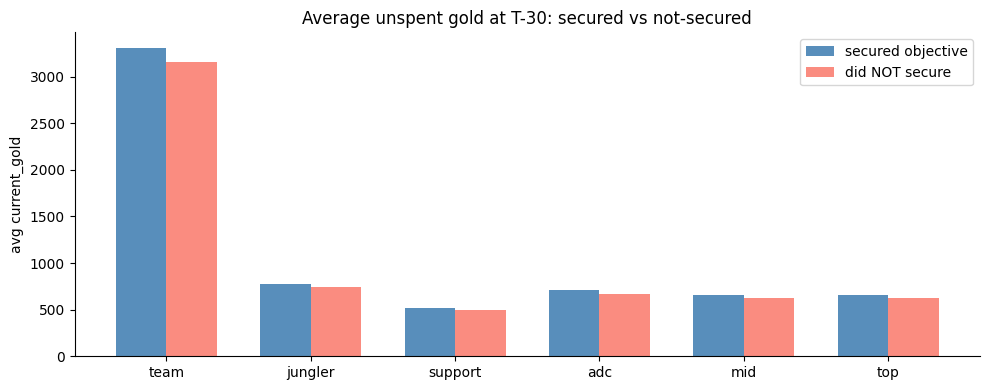

C:\Users\Laser\AppData\Local\Temp\ipykernel_133764\15341549.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_outcome, labels=order_by_median, showfliers=False)


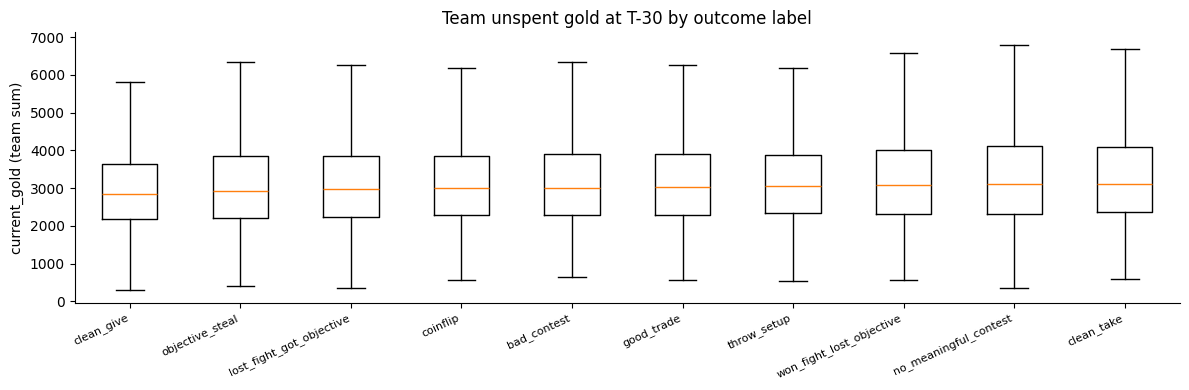

In [19]:
gold_roles = ['team', 'jungler', 'support', 'adc', 'mid', 'top']

# Avg unspent gold at T-30 by secured outcome
print(f'{"Role":<12}  {"Secured mean":>14} {"Not secured mean":>17} {"Diff":>8}')
print('-' * 55)
for role in gold_roles:
    col = f'{role}_unspent_gold_T_30'
    if col not in df.columns:
        continue
    secured_mean   = df[df['secured'] == 1][col].mean()
    unsecured_mean = df[df['secured'] == 0][col].mean()
    diff = secured_mean - unsecured_mean
    print(f'{col:<36}  {secured_mean:>8.0f}  {unsecured_mean:>10.0f}  {diff:>+8.0f}')

# Correlation with secured
print('\nCorrelation of unspent gold with secured:')
gold_cols = [f'{r}_unspent_gold_T_30' for r in gold_roles if f'{r}_unspent_gold_T_30' in df.columns]
gold_cols += [f'{r}_unspent_gold_T_60' for r in gold_roles if f'{r}_unspent_gold_T_60' in df.columns]
corrs = df[gold_cols + ['secured']].corr()['secured'].drop('secured').sort_values()
print(corrs.round(3).to_string())

# Chart: avg unspent gold at T-30 by secured=0 vs secured=1
fig, ax = plt.subplots(figsize=(10, 4))
role_cols_t30 = [f'{r}_unspent_gold_T_30' for r in gold_roles if f'{r}_unspent_gold_T_30' in df.columns]
x = range(len(role_cols_t30))
w = 0.35
means_secured    = [df[df['secured']==1][c].mean() for c in role_cols_t30]
means_unsecured  = [df[df['secured']==0][c].mean() for c in role_cols_t30]
ax.bar([xi - w/2 for xi in x], means_secured,   w, label='secured objective',  color='steelblue', alpha=0.9)
ax.bar([xi + w/2 for xi in x], means_unsecured, w, label='did NOT secure',     color='salmon',    alpha=0.9)
ax.set_xticks(list(x))
ax.set_xticklabels([c.replace('_unspent_gold_T_30', '') for c in role_cols_t30])
ax.set_title('Average unspent gold at T-30: secured vs not-secured')
ax.set_ylabel('avg current_gold')
ax.legend()
plt.tight_layout()
plt.show()

# Boxplot: team unspent gold by outcome label
fig, ax = plt.subplots(figsize=(12, 4))
order_by_median = (
    df.groupby('outcome_label')['team_unspent_gold_T_30']
    .median().sort_values().index.tolist()
)
data_by_outcome = [df[df['outcome_label'] == lbl]['team_unspent_gold_T_30'].dropna().values
                   for lbl in order_by_median]
ax.boxplot(data_by_outcome, labels=order_by_median, showfliers=False)
ax.set_title('Team unspent gold at T-30 by outcome label')
ax.set_ylabel('current_gold (team sum)')
plt.xticks(rotation=25, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

In [20]:
from lolobj.analysis.baseline_report import run_report
run_report(parquet_path)


Loaded 68334 rows from C:\Users\Laser\dig-baron\data\processed\objective_windows.parquet
Columns: ['match_id', 'objective_instance', 'objective_type', 'objective_number', 'objective_time_ms', 'team_id', 'team_side', 'rank_bucket', 'patch', 'monster_subtype', 'team_alive_T_30', 'team_alive_T_60', 'enemy_alive_T_30', 'enemy_alive_T_60', 'jungler_alive_T_30', 'jungler_alive_T_60', 'support_alive_T_30', 'support_alive_T_60', 'team_deaths_30s', 'team_deaths_60s', 'team_deaths_90s', 'enemy_deaths_30s', 'enemy_deaths_60s', 'team_nearby_T_90', 'team_nearby_T_60', 'team_nearby_T_30', 'enemy_nearby_T_90', 'enemy_nearby_T_60', 'enemy_nearby_T_30', 'jungler_dist_T_30', 'jungler_dist_T_60', 'support_dist_T_30', 'support_dist_T_60', 'mid_dist_T_30', 'mid_dist_T_60', 'arrived_first', 'gold_diff_T_30', 'gold_diff_T_60', 'jungler_level_diff_T_30', 'jungler_level_diff_T_60', 'wards_placed_120s', 'wards_killed_120s', 'previous_same_obj_team', 'previous_same_obj_enemy', 'jungler_unspent_gold_T_30', 'jung

## 13. Trade analysis by rank bracket

**Questions:**
- Which rank gives objectives most often, and how often does that become a *good trade* vs a *clean give*?
- Does trade efficiency (good trades / all gives) rise with rank?
- How does give-rate compare to bad-contest rate across ranks?

A "give" = `outcome_label in {clean_give, good_trade}` (team absent at T-30s, didn't secure).
A "good trade" = the subset where a tower or elite monster was taken in [T, T+120s].

**Important context from Section 5b:** Dragon 1, Dragon 2, and Grubs are frequently taken uncontested.
A team showing `gave_away` on D1/D2 is often the **expected default** -- the enemy jungler took it
before the team could rotate. We distinguish:

- **Natural gives** (D1, D2, Grubs) -- high give rates are normal; trade efficiency measures
  whether the team proactively exploited the opponent taking a solo objective
- **Strategic gives** (D3+, Baron) -- teams have had time to group; a give is a deliberate decision

Plot 3 highlights this split explicitly.


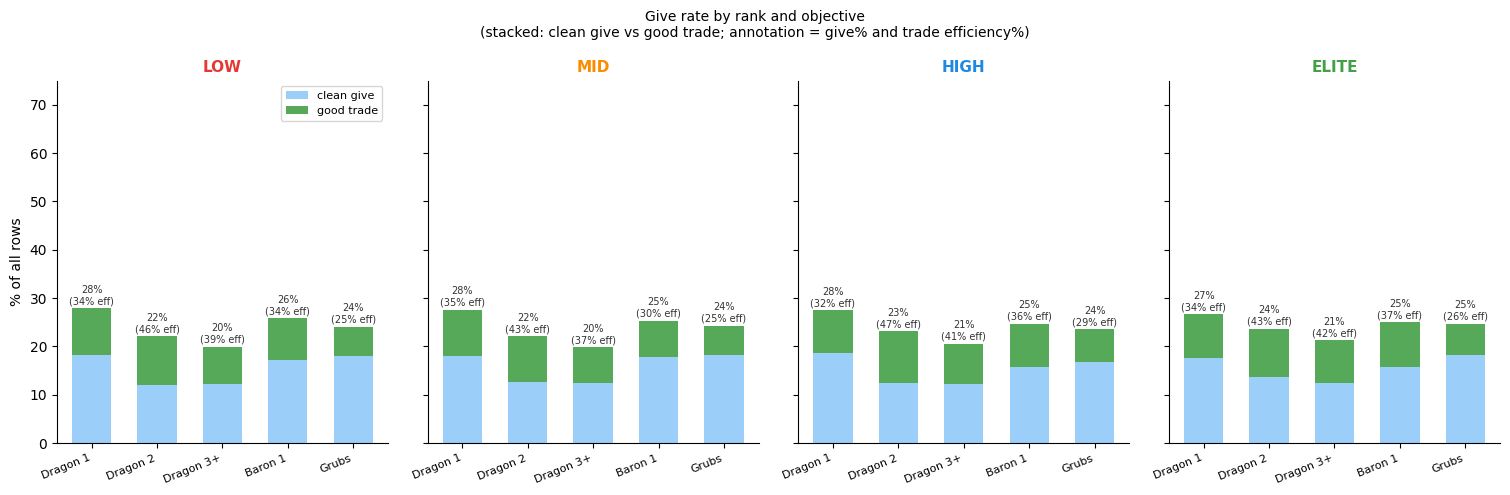

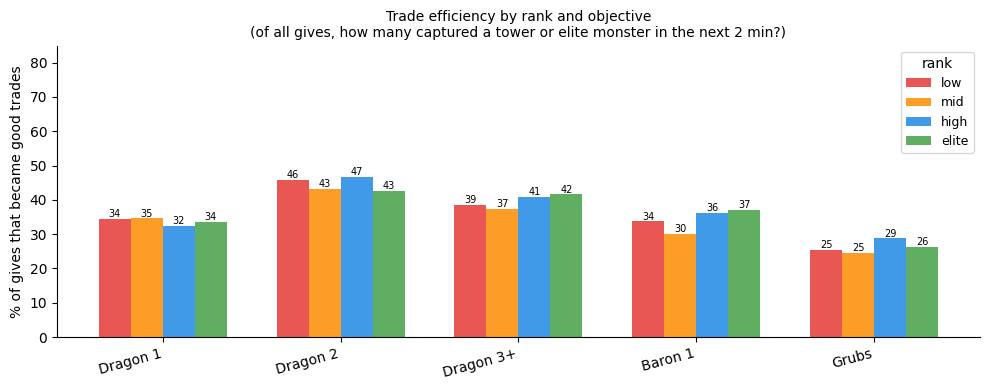

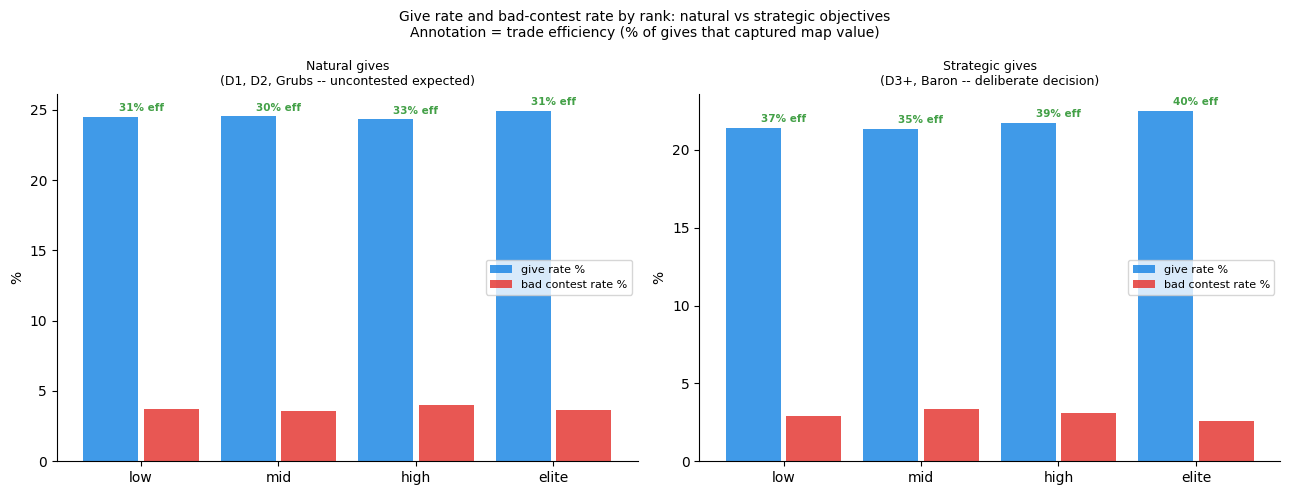


Rank summary (all objectives combined):
       give_rate  good_trade_rate  trade_efficiency  bad_contest_rate  throw_rate
rank                                                                             
low         23.9              8.5              35.7               3.4         9.2
mid         24.0              8.2              34.3               3.3         8.7
high        23.8              8.8              36.9               3.6         7.9
elite       24.3              8.8              36.3               3.2         7.8


In [21]:
import numpy as np

RANK_ORDER_PLOT = [r for r in ['low', 'mid', 'high', 'elite'] if r in df['rank_bucket'].values]

if not RANK_ORDER_PLOT:
    print('No ranked data available.')
else:
    if 'setup_profile' not in df.columns:
        from lolobj.analysis.baseline_report import assign_setup_profiles
        df['setup_profile'] = assign_setup_profiles(df)

    df_r = df[df['rank_bucket'].isin(RANK_ORDER_PLOT)].copy()

    NATURAL_GIVE_OBJS   = ['Dragon 1', 'Dragon 2', 'Grubs']
    STRATEGIC_GIVE_OBJS = ['Dragon 3+', 'Baron 1']

    OBJ_MASKS_RANK = {
        'Dragon 1':  (df_r['objective_type'] == 'DRAGON') & (df_r['objective_number'] == 1),
        'Dragon 2':  (df_r['objective_type'] == 'DRAGON') & (df_r['objective_number'] == 2),
        'Dragon 3+': (df_r['objective_type'] == 'DRAGON') & (df_r['objective_number'] >= 3),
        'Baron 1':   (df_r['objective_type'] == 'BARON_NASHOR') & (df_r['objective_number'] == 1),
        'Grubs':     df_r['objective_type'] == 'HORDE',
    }
    OBJ_LIST = [k for k, m in OBJ_MASKS_RANK.items() if df_r[m].shape[0] >= 30]

    records = []
    for rank in RANK_ORDER_PLOT:
        for obj_label, obj_mask in OBJ_MASKS_RANK.items():
            sub = df_r[obj_mask & (df_r['rank_bucket'] == rank)]
            if len(sub) < 30:
                continue
            n = len(sub)
            n_good  = (sub['outcome_label'] == 'good_trade').sum()
            n_clean = (sub['outcome_label'] == 'clean_give').sum()
            n_give  = n_good + n_clean
            records.append({
                'rank': rank, 'objective': obj_label, 'n': n,
                'give_rate':        n_give / n,
                'good_trade_rate':  n_good / n,
                'clean_give_rate':  n_clean / n,
                'trade_efficiency': n_good / n_give if n_give else 0,
                'bad_contest_rate': (sub['outcome_label'] == 'bad_contest').mean(),
                'throw_rate':       (sub['outcome_label'] == 'throw_setup').mean(),
            })

    rtdf = pd.DataFrame(records)
    RANK_COLORS = {'low': '#e53935', 'mid': '#fb8c00', 'high': '#1e88e5', 'elite': '#43a047'}
    avail_objs = [o for o in OBJ_LIST if o in rtdf['objective'].values]

    # Plot 1: stacked give rate by rank
    fig, axes = plt.subplots(1, len(RANK_ORDER_PLOT),
                              figsize=(3.8 * len(RANK_ORDER_PLOT), 5), sharey=True)
    xp = np.arange(len(avail_objs))
    w = 0.6
    for ax, rank in zip(axes, RANK_ORDER_PLOT):
        sub = rtdf[rtdf['rank'] == rank].set_index('objective')
        gt = [sub.loc[o, 'good_trade_rate'] * 100 if o in sub.index else 0 for o in avail_objs]
        cg = [sub.loc[o, 'clean_give_rate'] * 100  if o in sub.index else 0 for o in avail_objs]
        ax.bar(xp, cg, w, label='clean give',  color='#90CAF9', alpha=0.9)
        ax.bar(xp, gt, w, bottom=cg,           label='good trade', color='#43a047', alpha=0.9)
        ax.set_xticks(xp)
        ax.set_xticklabels(avail_objs, rotation=22, ha='right', fontsize=8)
        ax.set_title(rank.upper(), fontsize=11, fontweight='bold', color=RANK_COLORS.get(rank, '#333'))
        if ax is axes[0]:
            ax.set_ylabel('% of all rows')
        ax.set_ylim(0, 75)
        for i, o in enumerate(avail_objs):
            if o in sub.index:
                total = sub.loc[o, 'give_rate'] * 100
                eff   = sub.loc[o, 'trade_efficiency'] * 100
                ax.annotate(f'{total:.0f}%\n({eff:.0f}% eff)',
                             (i, total + 0.8), ha='center', fontsize=7, color='#333')
        if ax is axes[0]:
            ax.legend(fontsize=8)
    plt.suptitle('Give rate by rank and objective\n'
                 '(stacked: clean give vs good trade; annotation = give% and trade efficiency%)',
                 fontsize=10)
    plt.tight_layout()
    plt.show()

    # Plot 2: trade efficiency grouped bars
    fig, ax = plt.subplots(figsize=(max(10, len(avail_objs) * 2), 4))
    w2 = 0.18
    for i, rank in enumerate(RANK_ORDER_PLOT):
        sub = rtdf[rtdf['rank'] == rank].set_index('objective')
        eff = [sub.loc[o, 'trade_efficiency'] * 100 if o in sub.index else np.nan for o in avail_objs]
        offset = (i - len(RANK_ORDER_PLOT) / 2 + 0.5) * w2
        bars = ax.bar(np.arange(len(avail_objs)) + offset, eff, w2, label=rank,
                      color=RANK_COLORS.get(rank, '#888'), alpha=0.85)
        for bar, val in zip(bars, eff):
            if not np.isnan(val):
                ax.annotate(f'{val:.0f}', (bar.get_x() + bar.get_width()/2, val + 0.5),
                             ha='center', fontsize=7)
    ax.set_xticks(range(len(avail_objs)))
    ax.set_xticklabels(avail_objs, rotation=15, ha='right')
    ax.set_ylabel('% of gives that became good trades')
    ax.set_title('Trade efficiency by rank and objective\n'
                 '(of all gives, how many captured a tower or elite monster in the next 2 min?)',
                 fontsize=10)
    ax.legend(title='rank', fontsize=9)
    ax.set_ylim(0, 85)
    plt.tight_layout()
    plt.show()

    # Plot 3: natural gives vs strategic gives split by rank
    fig, axes3 = plt.subplots(1, 2, figsize=(13, 5))
    groups = [
        ('Natural gives\n(D1, D2, Grubs -- uncontested expected)', NATURAL_GIVE_OBJS),
        ('Strategic gives\n(D3+, Baron -- deliberate decision)', STRATEGIC_GIVE_OBJS),
    ]
    for ax, (group_label, group_objs) in zip(axes3, groups):
        grp = [o for o in group_objs if o in avail_objs]
        rank_effs = {}
        for rank in RANK_ORDER_PLOT:
            sub_r = rtdf[(rtdf['rank'] == rank) & rtdf['objective'].isin(grp)]
            if len(sub_r) == 0:
                continue
            total_n     = sub_r['n'].sum()
            total_gives = sub_r['give_rate'].mul(sub_r['n']).sum()
            total_good  = sub_r['good_trade_rate'].mul(sub_r['n']).sum()
            total_bad   = sub_r['bad_contest_rate'].mul(sub_r['n']).sum()
            rank_effs[rank] = {
                'give_rate':        total_gives / total_n * 100,
                'trade_efficiency': total_good / total_gives * 100 if total_gives > 0 else 0,
                'bad_contest_rate': total_bad  / total_n * 100,
            }
        if not rank_effs:
            ax.set_visible(False)
            continue
        ranks_avail = [r for r in RANK_ORDER_PLOT if r in rank_effs]
        xr = np.arange(len(ranks_avail))
        ax.bar(xr - 0.22, [rank_effs[r]['give_rate']        for r in ranks_avail],
               0.4, label='give rate %',        color='#1e88e5', alpha=0.85)
        ax.bar(xr + 0.22, [rank_effs[r]['bad_contest_rate'] for r in ranks_avail],
               0.4, label='bad contest rate %', color='#e53935', alpha=0.85)
        ax.set_xticks(xr)
        ax.set_xticklabels(ranks_avail)
        ax.set_ylabel('%')
        ax.set_title(group_label, fontsize=9)
        ax.legend(fontsize=8)
        for xi, rank in enumerate(ranks_avail):
            ax.annotate(f"{rank_effs[rank]['trade_efficiency']:.0f}% eff",
                        (xi, rank_effs[rank]['give_rate'] + 0.4),
                        ha='center', fontsize=7.5, color='#43a047', fontweight='bold')
    plt.suptitle(
        'Give rate and bad-contest rate by rank: natural vs strategic objectives\n'
        'Annotation = trade efficiency (% of gives that captured map value)',
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

    print('\nRank summary (all objectives combined):')
    rank_summary = []
    for rank in RANK_ORDER_PLOT:
        sub = df_r[df_r['rank_bucket'] == rank]
        gives = sub['outcome_label'].isin(['clean_give', 'good_trade'])
        rank_summary.append({
            'rank': rank,
            'give_rate':        gives.mean() * 100,
            'good_trade_rate':  (sub['outcome_label'] == 'good_trade').mean() * 100,
            'trade_efficiency': (sub['outcome_label'] == 'good_trade').sum() / gives.sum() * 100
                                if gives.sum() > 0 else 0,
            'bad_contest_rate': (sub['outcome_label'] == 'bad_contest').mean() * 100,
            'throw_rate':       (sub['outcome_label'] == 'throw_setup').mean() * 100,
        })
    rsdf = pd.DataFrame(rank_summary).set_index('rank')
    print(rsdf[['give_rate', 'good_trade_rate', 'trade_efficiency',
                'bad_contest_rate', 'throw_rate']].round(1).to_string())


## 14. Setup quality model + per-game objective analyser

Train a logistic regression on `FEATURES_KEEP` to predict the probability that a team secures a given objective. The model is used as a **diagnostic lens**, not a prediction engine: given a `match_id`, it assigns each team a predicted secure probability at each objective and decomposes the prediction into the top contributing features.

**Model design:**
- Train/test split is by `match_id` (no objective rows from the same match in both splits)
- Features are standardised before fitting so coefficients are directly comparable
- Feature contributions = `coef_i × scaled_feature_i` — positive means "pushed toward securing," negative means "pushed away"

**`analyze_game(match_id)`** accepts any match ID in the dataset and prints a per-objective breakdown with the 3 strongest factors for each team.

LogisticRegression on 31 features  |  train matches: 4  test matches: 1
Train AUC: 1.000  |  Test AUC: 1.000  |  Test Acc: 1.000  |  Test LogLoss: 0.125


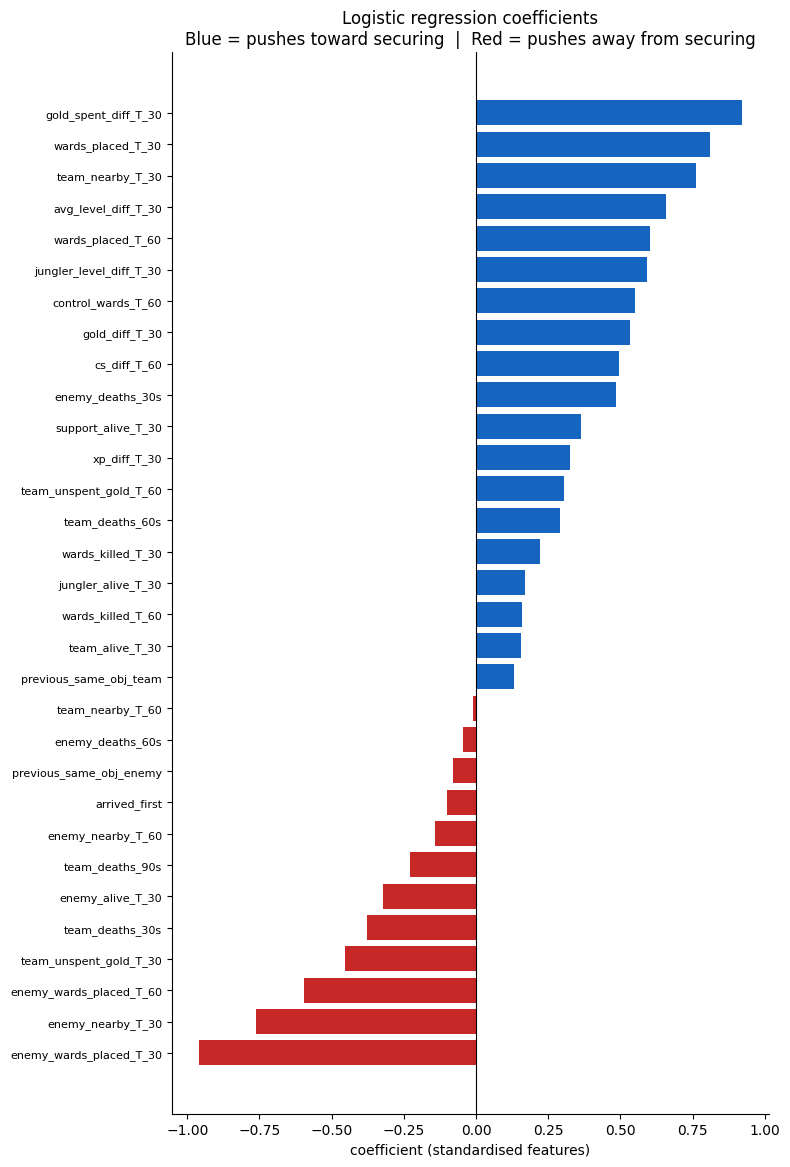

enemy_wards_placed_T_30   -0.960
enemy_nearby_T_30         -0.760
enemy_wards_placed_T_60   -0.595
team_unspent_gold_T_30    -0.454
team_deaths_30s           -0.378
enemy_alive_T_30          -0.321
team_deaths_90s           -0.228
enemy_nearby_T_60         -0.141
arrived_first             -0.102
previous_same_obj_enemy   -0.081
enemy_deaths_60s          -0.044
team_nearby_T_60          -0.010
previous_same_obj_team     0.132
team_alive_T_30            0.155
wards_killed_T_60          0.159
jungler_alive_T_30         0.171
wards_killed_T_30          0.222
team_deaths_60s            0.291
team_unspent_gold_T_60     0.305
xp_diff_T_30               0.324
support_alive_T_30         0.364
enemy_deaths_30s           0.484
cs_diff_T_60               0.496
gold_diff_T_30             0.535
control_wards_T_60         0.552
jungler_level_diff_T_30    0.591
wards_placed_T_60          0.602
avg_level_diff_T_30        0.657
team_nearby_T_30           0.762
wards_placed_T_30          0.812
gold_spent

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss
import numpy as np

if 'FEATURES_KEEP' not in dir():
    raise RuntimeError("Run the feature-filtering cell first to define FEATURES_KEEP.")

_FCOLS = [f for f in FEATURES_KEEP if f in df.columns]

_mdf = df.dropna(subset=_FCOLS).copy()
_X   = _mdf[_FCOLS].values.astype(float)
_y   = _mdf['secured'].values
_grp = _mdf['match_id'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
_tr, _te = next(gss.split(_X, _y, _grp))

_scaler = StandardScaler()
_Xtr = _scaler.fit_transform(_X[_tr])
_Xte = _scaler.transform(_X[_te])

_model = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')
_model.fit(_Xtr, _y[_tr])

_tr_auc = roc_auc_score(_y[_tr], _model.predict_proba(_Xtr)[:, 1])
_te_auc = roc_auc_score(_y[_te], _model.predict_proba(_Xte)[:, 1])
_te_acc = accuracy_score(_y[_te], _model.predict(_Xte))
_te_ll  = log_loss(_y[_te], _model.predict_proba(_Xte))

print(f"LogisticRegression on {len(_FCOLS)} features  |  "
      f"train matches: {len(set(_grp[_tr])):,}  test matches: {len(set(_grp[_te])):,}")
print(f"Train AUC: {_tr_auc:.3f}  |  Test AUC: {_te_auc:.3f}  |  "
      f"Test Acc: {_te_acc:.3f}  |  Test LogLoss: {_te_ll:.3f}")

# Coefficient chart
_coef = pd.Series(_model.coef_[0], index=_FCOLS).sort_values()
colors_c = ['#c62828' if v < 0 else '#1565c0' for v in _coef]
fig, ax = plt.subplots(figsize=(8, max(5, len(_coef) * 0.38)))
ax.barh(range(len(_coef)), _coef.values, color=colors_c)
ax.set_yticks(range(len(_coef)))
ax.set_yticklabels(_coef.index, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('coefficient (standardised features)')
ax.set_title('Logistic regression coefficients\n'
             'Blue = pushes toward securing  |  Red = pushes away from securing')
plt.tight_layout()
plt.show()
print(_coef.round(3).to_string())

Demo — running analyze_game on: EUW1_7108550527
To analyse a different match call:  analyze_game('YOUR_MATCH_ID')


══════════════════════════════════════════════════════════════════════════
  MATCH  EUW1_7108550527
  Rank: low   Patch: 14.17.615.2328   Objectives: 14
══════════════════════════════════════════════════════════════════════════

  ── HORDE #1  @6:41  secured by: BLUE ──
                     BLUE                                RED                
      ----------------------------------  ----------------------------------

  [BLUE ✓]  prob=51%   net_value=+7
    outcome : no_meaningful_contest
    profile : both_absent
    gold diff T-30 : +868g
    nearby T-30    : team=0  enemy=0
    deaths 60s/30s : 1 / 1
    jg alive T-30  : 1   arrived first: 0
    ↑ top factors  : enemy_wards_placed_T_30(+0.70)  enemy_nearby_T_30(+0.58)  enemy_wards_placed_T_60(+0.47)
    ↓ top factors  : wards_placed_T_30(-0.59)  team_nearby_T_30(-0.58)  wards_placed_T_60(-0.48)

  [RED   ]  prob=52

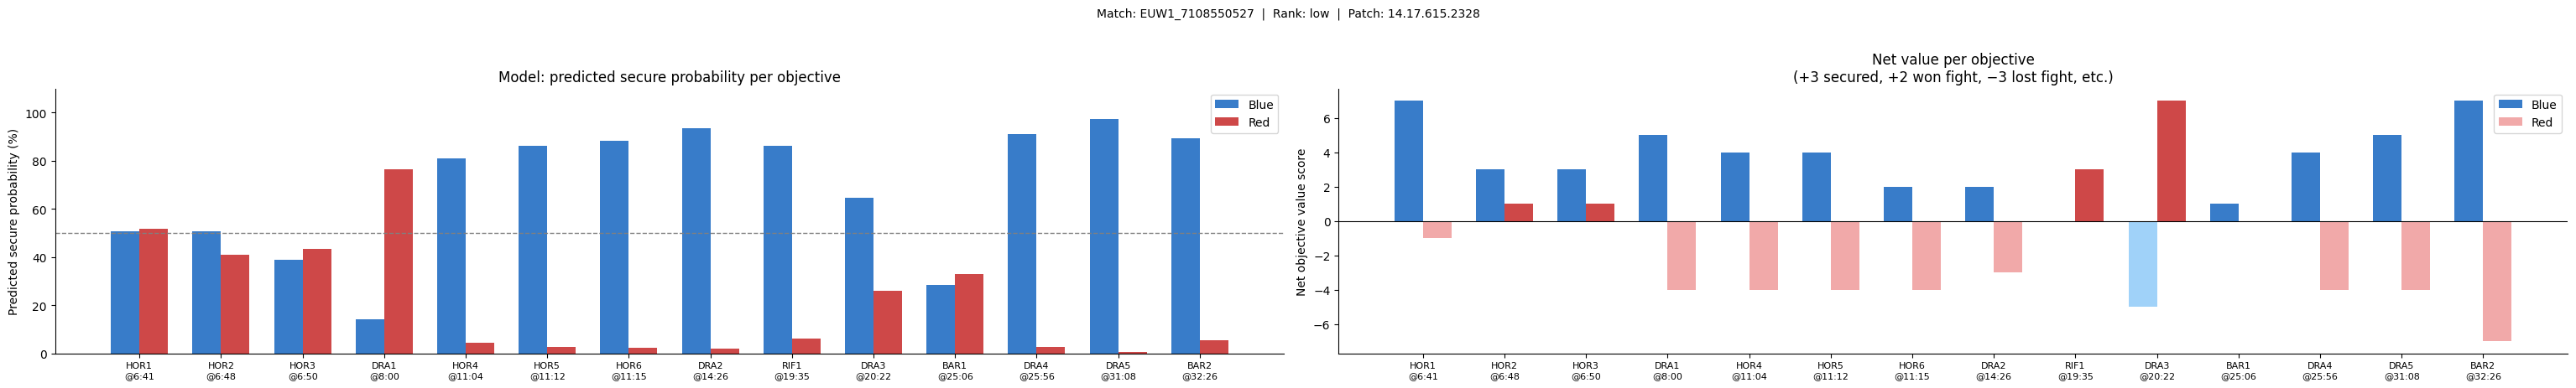

In [23]:
def analyze_game(match_id: str, top_n: int = 3):
    """
    Print a per-objective breakdown for one match.

    For every objective in the game, shows each team's predicted secure
    probability, their setup profile, actual outcome, net_value score, key
    raw feature values, and the top contributing features (log-odds units).

    Parameters
    ----------
    match_id : str   e.g. "NA1_1234567890"
    top_n    : int   number of top positive/negative factors to show per team
    """
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import numpy as np

    game = df[df['match_id'] == match_id].copy()
    if game.empty:
        print(f"Match '{match_id}' not found. "
              f"Dataset has {df['match_id'].nunique():,} matches.")
        print(f"Sample IDs: {df['match_id'].sample(min(5, len(df))).tolist()}")
        return

    if 'setup_profile' not in game.columns:
        from lolobj.analysis.baseline_report import assign_setup_profiles
        game['setup_profile'] = assign_setup_profiles(game)

    X_g    = game[_FCOLS].fillna(0).values.astype(float)
    Xs_g   = _scaler.transform(X_g)
    probs  = _model.predict_proba(Xs_g)[:, 1]
    contribs = Xs_g * _model.coef_[0]          # (n_rows, n_features)
    game = game.copy()
    game['_prob']  = probs
    game['_gidx']  = range(len(game))           # position in game sub-df

    rank  = game['rank_bucket'].iloc[0]
    patch = game['patch'].iloc[0]

    objs = (game.drop_duplicates('objective_instance')
                .sort_values('objective_time_ms')
                [['objective_instance', 'objective_type',
                  'objective_number', 'objective_time_ms']])

    print(f"\n{'═'*74}")
    print(f"  MATCH  {match_id}")
    print(f"  Rank: {rank}   Patch: {patch}   Objectives: {len(objs)}")
    print(f"{'═'*74}")

    all_blue_probs, all_red_probs = [], []
    all_blue_nv,    all_red_nv    = [], []
    xlabels = []

    for _, obj in objs.iterrows():
        inst     = obj['objective_instance']
        otype    = obj['objective_type']
        onum     = int(obj['objective_number'])
        secs     = obj['objective_time_ms'] / 1000
        ts       = f"{int(secs//60)}:{int(secs%60):02d}"

        teams    = game[game['objective_instance'] == inst]
        secured_side = teams[teams['secured'] == 1]['team_side'].values
        winner   = secured_side[0] if len(secured_side) else '?'

        print(f"\n  ── {otype} #{onum}  @{ts}  secured by: {winner.upper()} ──")
        print(f"  {'':4}{'BLUE':^34}  {'RED':^34}")
        print(f"  {'':4}{'-'*34}  {'-'*34}")

        blue = teams[teams['team_side'] == 'blue']
        red  = teams[teams['team_side']  == 'red']

        bprob, rprob = (blue['_prob'].iloc[0] if not blue.empty else 0.5,
                        red['_prob'].iloc[0]  if not red.empty  else 0.5)
        bnv   = blue['net_value'].iloc[0] if (not blue.empty and 'net_value' in blue.columns) else 0
        rnv   = red['net_value'].iloc[0]  if (not red.empty  and 'net_value' in red.columns)  else 0

        all_blue_probs.append(bprob * 100)
        all_red_probs.append(rprob  * 100)
        all_blue_nv.append(bnv)
        all_red_nv.append(rnv)
        xlabels.append(f"{otype[:3]}{onum}\n@{ts}")

        for side_label, sdf in [('BLUE ✓' if winner == 'blue' else 'BLUE  ', blue),
                                  ('RED  ✓' if winner == 'red'  else 'RED   ', red)]:
            if sdf.empty:
                continue
            row   = sdf.iloc[0]
            gi    = int(row['_gidx'])
            ctrib = contribs[gi]

            pos = sorted(zip(_FCOLS, ctrib), key=lambda x: x[1], reverse=True)[:top_n]
            neg = sorted(zip(_FCOLS, ctrib), key=lambda x: x[1])[:top_n]

            print(f"\n  [{side_label}]  prob={row['_prob']:.0%}   "
                  f"net_value={int(bnv if 'BLUE' in side_label else rnv):+d}")
            print(f"    outcome : {row['outcome_label']}")
            print(f"    profile : {row.get('setup_profile', 'n/a')}")
            print(f"    gold diff T-30 : {row.get('gold_diff_T_30', float('nan')):+.0f}g")
            print(f"    nearby T-30    : team={int(row.get('team_nearby_T_30',0))}  "
                  f"enemy={int(row.get('enemy_nearby_T_30',0))}")
            print(f"    deaths 60s/30s : {int(row.get('team_deaths_60s',0))} / "
                  f"{int(row.get('team_deaths_30s',0))}")
            print(f"    jg alive T-30  : {int(row.get('jungler_alive_T_30',0))}   "
                  f"arrived first: {int(row.get('arrived_first',0))}")
            print(f"    ↑ top factors  : "
                  + "  ".join(f"{n}({v:+.2f})" for n, v in pos))
            print(f"    ↓ top factors  : "
                  + "  ".join(f"{n}({v:+.2f})" for n, v in neg))

    print(f"\n{'═'*74}\n")

    # ── Summary chart ──────────────────────────────────────────────────────
    n_obj = len(xlabels)
    if n_obj == 0:
        return

    fig, axes = plt.subplots(1, 2, figsize=(max(8, n_obj * 2.2), 4.5))
    xpos = np.arange(n_obj)
    w    = 0.35

    axes[0].bar(xpos - w/2, all_blue_probs, w, label='Blue', color='#1565c0', alpha=0.85)
    axes[0].bar(xpos + w/2, all_red_probs,  w, label='Red',  color='#c62828', alpha=0.85)
    axes[0].axhline(50, color='gray', linestyle='--', linewidth=1)
    axes[0].set_xticks(xpos)
    axes[0].set_xticklabels(xlabels, fontsize=8)
    axes[0].set_ylabel('Predicted secure probability (%)')
    axes[0].set_title('Model: predicted secure probability per objective')
    axes[0].set_ylim(0, 110)
    axes[0].legend()

    b_nv_colors = ['#1565c0' if v >= 0 else '#90CAF9' for v in all_blue_nv]
    r_nv_colors = ['#c62828' if v >= 0 else '#ef9a9a' for v in all_red_nv]
    axes[1].bar(xpos - w/2, all_blue_nv, w, label='Blue', color=b_nv_colors, alpha=0.85)
    axes[1].bar(xpos + w/2, all_red_nv,  w, label='Red',  color=r_nv_colors, alpha=0.85)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xticks(xpos)
    axes[1].set_xticklabels(xlabels, fontsize=8)
    axes[1].set_ylabel('Net objective value score')
    axes[1].set_title('Net value per objective\n(+3 secured, +2 won fight, −3 lost fight, etc.)')
    axes[1].legend()

    plt.suptitle(f'Match: {match_id}  |  Rank: {rank}  |  Patch: {patch}',
                 fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()


# ── Demo: run on the first match in the dataset ───────────────────────────
_demo_id = df['match_id'].iloc[0]
print(f"Demo — running analyze_game on: {_demo_id}")
print("To analyse a different match call:  analyze_game('YOUR_MATCH_ID')\n")
analyze_game(_demo_id)

## 15. Random Forest + SHAP explainer

Adds a Random Forest model alongside logistic regression to capture non-linear
relationships and feature interactions that LR cannot model.

**What changes from Section 14:**
- Predicted probability from RF is the confidence score for each objective
- SHAP values (TreeExplainer) replace coefficient x feature for per-game explanations
- Interactions are captured: deaths + gold deficit compound correctly
- Confidence labels: >70% or <30% = high confidence; 40-60% = uncertain/coin-flip range

Requires shap: `pip install shap`

**Train / test split:** 70% train, 30% test, grouped by match_id (no objective rows
from the same game bleed across splits).

**Why keep LR alongside RF:** LR coefficients give clean global marginal effects.
RF + SHAP gives per-prediction, context-aware attributions. Both together are
stronger than either alone for explaining why objectives went a certain way.

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
import numpy as np

if "FEATURES_KEEP" not in dir() or "_CANDIDATE_FEATURES" not in dir():
    raise RuntimeError("Run the feature-filtering cell first.")

feat_cols_kept = [c for c in FEATURES_KEEP         if c in df.columns]
feat_cols_all  = [c for c in _CANDIDATE_FEATURES   if c in df.columns]

y_all   = df["secured"].values
grp_arr = df["match_id"].values

# Single split shared across all three models for apples-to-apples comparison
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(gss.split(df[feat_cols_all], y_all, grp_arr))
y_train = y_all[train_idx]
y_test  = y_all[test_idx]
print("Train:", len(y_train), "rows |", round(y_train.mean()*100, 1), "% secured")
print("Test: ", len(y_test),  "rows |", round(y_test.mean()*100,  1), "% secured")

# --- LR on FEATURES_KEEP ---
X_train_k = df[feat_cols_kept].fillna(0).iloc[train_idx]
X_test_k  = df[feat_cols_kept].fillna(0).iloc[test_idx]
sc15 = StandardScaler()
lr15 = LogisticRegression(max_iter=1000, C=0.5, random_state=42)
lr15.fit(sc15.fit_transform(X_train_k), y_train)
lr_prob_test = lr15.predict_proba(sc15.transform(X_test_k))[:, 1]

# --- RF on FEATURES_KEEP ---
_rf_params = dict(n_estimators=500, max_features="sqrt",
                  min_samples_leaf=20, oob_score=True, n_jobs=-1, random_state=42)
rf_kept = RandomForestClassifier(**_rf_params)
rf_kept.fit(X_train_k, y_train)
rf_kept_prob = rf_kept.predict_proba(X_test_k)[:, 1]

# --- RF on all candidates (no sibling-dropping, no weak-signal filter) ---
X_train_all = df[feat_cols_all].fillna(0).iloc[train_idx]
X_test_all  = df[feat_cols_all].fillna(0).iloc[test_idx]
rf_all = RandomForestClassifier(**_rf_params)
rf_all.fit(X_train_all, y_train)
rf_all_prob = rf_all.predict_proba(X_test_all)[:, 1]

print("RF-kept OOB:", round(rf_kept.oob_score_, 3),
      " | RF-all OOB:", round(rf_all.oob_score_, 3))

# Auto-select the better RF for downstream SHAP / analyze_game cells
if roc_auc_score(y_test, rf_all_prob) >= roc_auc_score(y_test, rf_kept_prob):
    rf, feat_cols, rf_prob_test, X_test_raw = rf_all, feat_cols_all, rf_all_prob, X_test_all
    print("Downstream cells will use RF-all")
else:
    rf, feat_cols, rf_prob_test, X_test_raw = rf_kept, feat_cols_kept, rf_kept_prob, X_test_k
    print("Downstream cells will use RF-kept")

# Three-way comparison table
print()
print("{:<28}  {:>6}  {:>9}  {:>7}  {:>10}".format(
    "Model", "AUC", "Log-loss", "Brier", "# features"))
print("-" * 68)
for _n, _p, _nf in [
    ("LR  (FEATURES_KEEP)",    lr_prob_test,  len(feat_cols_kept)),
    ("RF  (FEATURES_KEEP)",    rf_kept_prob,  len(feat_cols_kept)),
    ("RF  (all candidates)",   rf_all_prob,   len(feat_cols_all)),
]:
    _auc = roc_auc_score(y_test, _p)
    _ll  = log_loss(y_test, _p)
    _bs  = brier_score_loss(y_test, _p)
    print("{:<28}  {:.4f}  {:>9.4f}  {:>7.4f}  {:>10}".format(_n, _auc, _ll, _bs, _nf))


Train: 47726 rows | 49.3 % secured
Test:  20608 rows | 49.3 % secured
RF-kept OOB: 0.837  | RF-all OOB: 0.837
Downstream cells will use RF-kept

Model                            AUC   Log-loss    Brier  # features
--------------------------------------------------------------------
LR  (FEATURES_KEEP)           0.9005     0.4037   0.1260          31
RF  (FEATURES_KEEP)           0.9085     0.3941   0.1223          31
RF  (all candidates)          0.9077     0.3978   0.1235          48


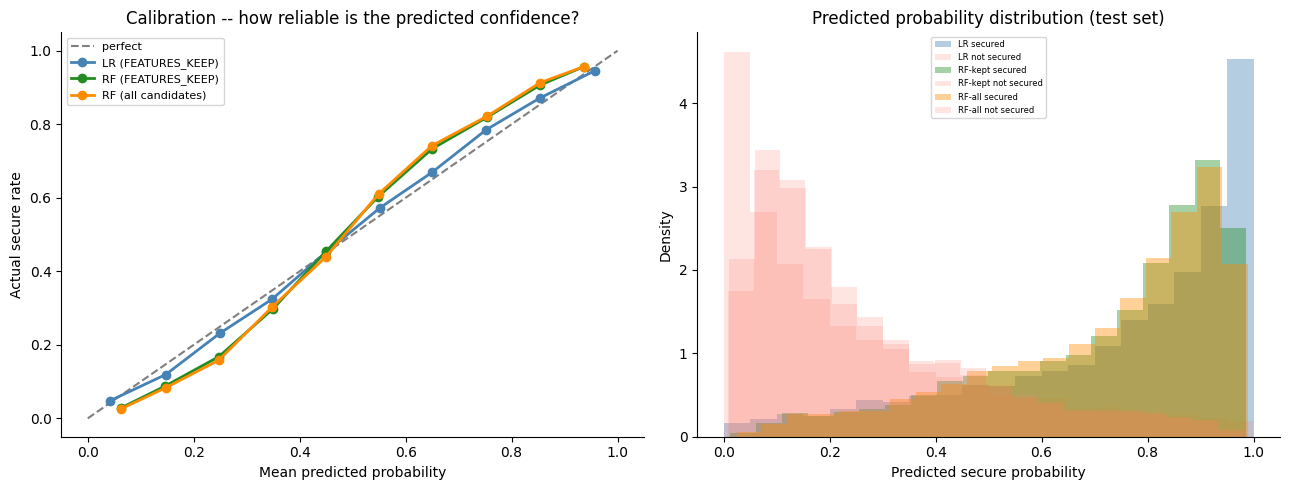

Confidence distribution (chosen RF, test set):
  high (>70% or <30%)             72.3%
  uncertain (40-60%)              14.0%
  moderate (60-70% or 30-40%)     13.7%


In [25]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Calibration curves -- all three models
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect")
for _name, _prob, _col in [
    ("LR (FEATURES_KEEP)",  lr_prob_test,  "steelblue"),
    ("RF (FEATURES_KEEP)",  rf_kept_prob,  "forestgreen"),
    ("RF (all candidates)", rf_all_prob,   "darkorange"),
]:
    _fp, _mp = calibration_curve(y_test, _prob, n_bins=10)
    ax.plot(_mp, _fp, marker="o", label=_name, color=_col, linewidth=2)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual secure rate")
ax.set_title("Calibration -- how reliable is the predicted confidence?")
ax.legend(fontsize=8)

# Predicted probability distributions
ax2 = axes[1]
for _name, _prob, _col in [
    ("LR",           lr_prob_test,  "steelblue"),
    ("RF-kept",      rf_kept_prob,  "forestgreen"),
    ("RF-all",       rf_all_prob,   "darkorange"),
]:
    ax2.hist(_prob[y_test == 1], bins=20, alpha=0.4, color=_col,
             label=_name + " secured", density=True)
    ax2.hist(_prob[y_test == 0], bins=20, alpha=0.2, color="salmon",
             label=_name + " not secured", density=True)
ax2.set_xlabel("Predicted secure probability")
ax2.set_ylabel("Density")
ax2.set_title("Predicted probability distribution (test set)")
ax2.legend(fontsize=6)

plt.tight_layout()
plt.show()

# Confidence bucket summary for the chosen RF
def _conf_label(p):
    m = abs(p - 0.5)
    if m > 0.20: return "high (>70% or <30%)"
    if m > 0.10: return "moderate (60-70% or 30-40%)"
    return "uncertain (40-60%)"

rf_conf    = [_conf_label(p) for p in rf_prob_test]
conf_pct   = (pd.Series(rf_conf).value_counts() / len(rf_conf) * 100).round(1)
print("Confidence distribution (chosen RF, test set):")
for bucket, pct in conf_pct.items():
    print(f"  {bucket:<30}  {pct}%")


SHAP mean |value| per feature (top 15):
  arrived_first                               0.0990
  enemy_nearby_T_30                           0.0779
  team_nearby_T_30                            0.0675
  previous_same_obj_team                      0.0528
  gold_diff_T_30                              0.0524
  enemy_deaths_60s                            0.0460
  previous_same_obj_enemy                     0.0410
  team_deaths_60s                             0.0383
  enemy_alive_T_30                            0.0242
  team_deaths_90s                             0.0229
  jungler_alive_T_30                          0.0183
  team_deaths_30s                             0.0168
  enemy_deaths_30s                            0.0160
  team_alive_T_30                             0.0154
  jungler_level_diff_T_30                     0.0102


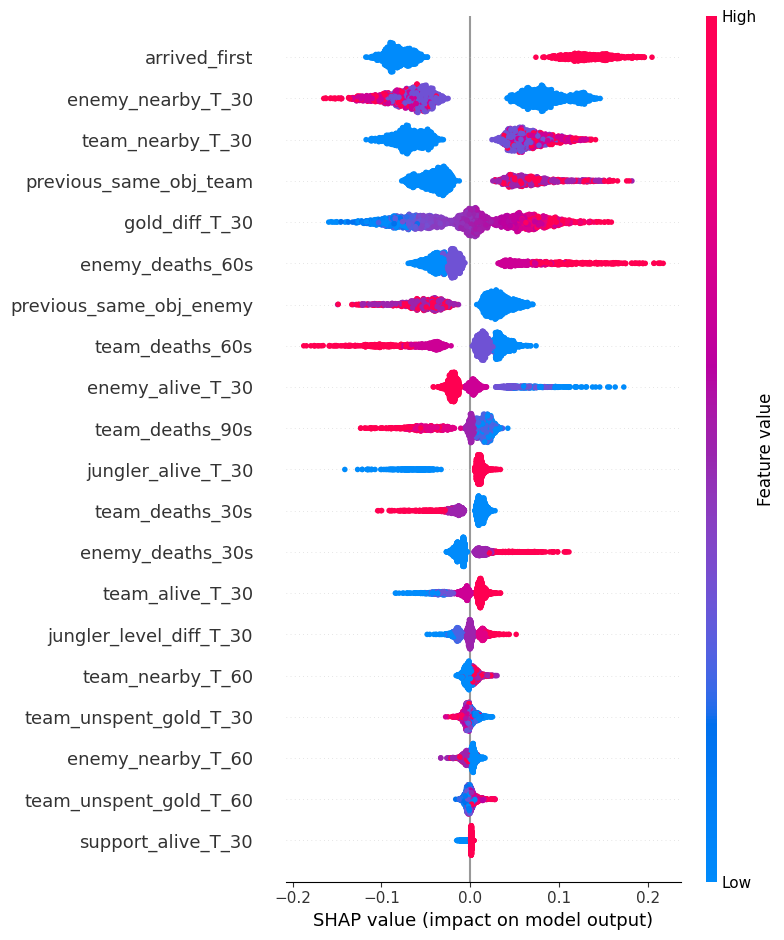

In [26]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap not installed. Run: pip install shap")

if HAS_SHAP:
    rf_explainer = shap.TreeExplainer(rf)
    _N     = min(2000, len(X_test_raw))
    _X_sh  = X_test_raw.iloc[:_N]
    _sv    = rf_explainer.shap_values(_X_sh)
    # binary RF: shap_values returns [class0_arr, class1_arr] or 3-D array
    if isinstance(_sv, list):
        _sv_pos = _sv[1]
    elif hasattr(_sv, "ndim") and _sv.ndim == 3:
        _sv_pos = _sv[:, :, 1]
    else:
        _sv_pos = _sv
    print("SHAP mean |value| per feature (top 15):")
    _mean_abs = np.abs(_sv_pos).mean(axis=0)
    for _feat, _imp in sorted(zip(feat_cols, _mean_abs), key=lambda x: -x[1])[:15]:
        print(f"  {_feat:<42}  {_imp:.4f}")
    shap.summary_plot(_sv_pos, _X_sh, feature_names=feat_cols, max_display=20)
else:
    print("Install shap to see feature importance: pip install shap")

In [27]:
def analyze_game_rf(match_id: str, top_n: int = 4) -> None:
    """Per-objective SHAP breakdown with confidence labels."""
    if not HAS_SHAP:
        print("shap not installed -- pip install shap")
        return
    _rows = df[df["match_id"] == match_id].copy()
    if _rows.empty:
        print("match_id " + repr(match_id) + " not found.")
        return
    if "setup_profile" not in _rows.columns:
        from lolobj.analysis.baseline_report import assign_setup_profiles
        _rows["setup_profile"] = assign_setup_profiles(_rows)
    _n_obj = _rows["objective_instance"].nunique()
    print("Match " + match_id + "  (" + str(_n_obj) + " objectives)")
    for _inst in sorted(_rows["objective_instance"].unique()):
        _obj   = _rows[_rows["objective_instance"] == _inst].sort_values("team_id")
        _otype = _obj["objective_type"].iloc[0]
        _onum  = int(_obj["objective_number"].iloc[0])
        print()
        print("=" * 58)
        print(_otype + " #" + str(_onum))
        print("=" * 58)
        for _, _r in _obj.iterrows():
            _X    = pd.DataFrame([_r[feat_cols].fillna(0)], columns=feat_cols)
            _prob = rf.predict_proba(_X)[0, 1]
            _m    = abs(_prob - 0.5)
            if _m > 0.20:
                _conf = "high confidence"
            elif _m > 0.10:
                _conf = "moderate"
            else:
                _conf = "uncertain (coin-flip range)"
            _sv_r = rf_explainer.shap_values(_X)
            if isinstance(_sv_r, list):
                _sv = _sv_r[1][0]
            elif hasattr(_sv_r, "ndim") and _sv_r.ndim == 3:
                _sv = _sv_r[0, :, 1]
            else:
                _sv = _sv_r[0]
            _top = np.argsort(np.abs(_sv))[::-1][:top_n]
            _secured_str = "SECURED" if _r["secured"] else "not secured"
            print("  " + _r["team_side"].upper() + " (team " + str(int(_r["team_id"])) + ")")
            print("  Predicted : " + str(round(_prob * 100)) + "% secure  [" + _conf + "]")
            print("  Actual    : " + _secured_str + "  |  outcome: " + _r["outcome_label"])
            print("  Profile   : " + str(_r.get("setup_profile", "N/A")))
            print("  Factors   :")
            for _i in _top:
                _feat  = feat_cols[_i]
                _raw   = _r[feat_cols[_i]]
                _shap  = _sv[_i]
                _arrow = "+" if _shap > 0 else "-"
                _sign  = "+" if _shap >= 0 else ""
                _line  = ("    [" + _arrow + "] " + _feat.ljust(38)
                          + "  raw=" + str(_raw)
                          + "  SHAP=" + _sign + str(round(float(_shap), 3)))
                print(_line)
        print()

# Demo on first available match
_demo_id = df["match_id"].iloc[0]
print("Demo: analyze_game_rf('" + _demo_id + "')")
analyze_game_rf(_demo_id)

Demo: analyze_game_rf('EUW1_7108550527')
Match EUW1_7108550527  (14 objectives)

BARON_NASHOR #1
  BLUE (team 100)
  Predicted : 50% secure  [uncertain (coin-flip range)]
  Actual    : not secured  |  outcome: won_fight_lost_objective
  Profile   : free_setup_deaths
  Factors   :
    [+] arrived_first                           raw=1  SHAP=+0.154
    [-] jungler_alive_T_30                      raw=0  SHAP=-0.122
    [-] team_deaths_90s                         raw=4  SHAP=-0.09
    [-] team_alive_T_30                         raw=1  SHAP=-0.062


C:\Users\Laser\AppData\Local\Temp\ipykernel_133764\2528339310.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _X    = pd.DataFrame([_r[feat_cols].fillna(0)], columns=feat_cols)
C:\Users\Laser\AppData\Local\Temp\ipykernel_133764\2528339310.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _X    = pd.DataFrame([_r[feat_cols].fillna(0)], columns=feat_cols)


  RED (team 200)
  Predicted : 32% secure  [moderate]
  Actual    : SECURED  |  outcome: objective_steal
  Profile   : gave_away
  Factors   :
    [+] enemy_alive_T_30                        raw=1  SHAP=+0.119
    [-] enemy_nearby_T_30                       raw=1  SHAP=-0.084
    [-] arrived_first                           raw=0  SHAP=-0.075
    [-] team_nearby_T_30                        raw=0  SHAP=-0.074


BARON_NASHOR #2
  BLUE (team 100)
  Predicted : 88% secure  [high confidence]
  Actual    : SECURED  |  outcome: clean_take
  Profile   : clean_contest
  Factors   :
    [+] enemy_deaths_60s                        raw=4  SHAP=+0.133
    [+] arrived_first                           raw=1  SHAP=+0.121
    [+] team_nearby_T_30                        raw=4  SHAP=+0.111
    [+] enemy_deaths_30s                        raw=4  SHAP=+0.066


C:\Users\Laser\AppData\Local\Temp\ipykernel_133764\2528339310.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _X    = pd.DataFrame([_r[feat_cols].fillna(0)], columns=feat_cols)
C:\Users\Laser\AppData\Local\Temp\ipykernel_133764\2528339310.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _X    = pd.DataFrame([_r[feat_cols].fillna(0)], columns=feat_cols)


  RED (team 200)
  Predicted : 9% secure  [high confidence]
  Actual    : not secured  |  outcome: throw_setup
  Profile   : disadvantaged
  Factors   :
    [-] team_deaths_60s                         raw=4  SHAP=-0.13
    [-] enemy_nearby_T_30                       raw=4  SHAP=-0.129
    [-] team_deaths_30s                         raw=4  SHAP=-0.069
    [-] team_deaths_90s                         raw=4  SHAP=-0.069


DRAGON #1
  BLUE (team 100)
  Predicted : 20% secure  [high confidence]
  Actual    : SECURED  |  outcome: objective_steal
  Profile   : gave_away
  Factors   :
    [-] team_deaths_60s                         raw=3  SHAP=-0.083
    [-] enemy_nearby_T_30                       raw=2  SHAP=-0.079
    [-] arrived_first                           raw=0  SHAP=-0.075
    [-] team_nearby_T_30                        raw=0  SHAP=-0.069


...

  RED (team 200)
  Predicted : 11% secure  [high confidence]
  Actual    : not secured  |  outcome: good_trade
  Profile   : gave_away
  Factors   :
    [-] team_deaths_60s                         raw=4  SHAP=-0.101
    [-] arrived_first                           raw=0  SHAP=-0.066
    [-] team_deaths_90s                         raw=4  SHAP=-0.061
    [-] team_nearby_T_30                        raw=0  SHAP=-0.06


HORDE #5
  BLUE (team 100)
  Predicted : 93% secure  [high confidence]
  Actual    : SECURED  |  outcome: clean_take
  Profile   : free_setup_deaths
  Factors   :
    [+] arrived_first                           raw=1  SHAP=+0.105
    [+] enemy_deaths_60s                        raw=4  SHAP=+0.097
    [+] enemy_nearby_T_30                       raw=0  SHAP=+0.062
    [+] enemy_alive_T_30                        raw=2  SHAP=+0.052


C:\Users\Laser\AppData\Local\Temp\ipykernel_133764\2528339310.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _X    = pd.DataFrame([_r[feat_cols].fillna(0)], columns=feat_cols)
C:\Users\Laser\AppData\Local\Temp\ipykernel_133764\2528339310.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _X    = pd.DataFrame([_r[feat_cols].fillna(0)], columns=feat_cols)


  RED (team 200)
  Predicted : 9% secure  [high confidence]
  Actual    : not secured  |  outcome: good_trade
  Profile   : gave_away
  Factors   :
    [-] team_deaths_60s                         raw=4  SHAP=-0.091
    [-] arrived_first                           raw=0  SHAP=-0.066
    [-] team_nearby_T_30                        raw=0  SHAP=-0.061
    [-] enemy_nearby_T_30                       raw=1  SHAP=-0.051


HORDE #6
  BLUE (team 100)
  Predicted : 93% secure  [high confidence]
  Actual    : SECURED  |  outcome: clean_take
  Profile   : free_setup_deaths
  Factors   :
    [+] arrived_first                           raw=1  SHAP=+0.105
    [+] enemy_deaths_60s                        raw=4  SHAP=+0.097
    [+] enemy_nearby_T_30                       raw=0  SHAP=+0.062
    [+] enemy_alive_T_30                        raw=2  SHAP=+0.052


C:\Users\Laser\AppData\Local\Temp\ipykernel_133764\2528339310.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _X    = pd.DataFrame([_r[feat_cols].fillna(0)], columns=feat_cols)
C:\Users\Laser\AppData\Local\Temp\ipykernel_133764\2528339310.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _X    = pd.DataFrame([_r[feat_cols].fillna(0)], columns=feat_cols)


  RED (team 200)
  Predicted : 9% secure  [high confidence]
  Actual    : not secured  |  outcome: good_trade
  Profile   : gave_away
  Factors   :
    [-] team_deaths_60s                         raw=4  SHAP=-0.091
    [-] arrived_first                           raw=0  SHAP=-0.066
    [-] team_nearby_T_30                        raw=0  SHAP=-0.061
    [-] enemy_nearby_T_30                       raw=1  SHAP=-0.051



## 16. State-first objective setup analysis

**Core idea:** temporal ordering separates *what was already true* from *what teams chose to do*.

| Layer | Time window | What it captures |
|-------|-------------|------------------|
| **State** | T-60 and earlier | Gold deficit, alive-counts, recent deaths — the situation before teams commit to setup |
| **Action / setup** | T-60 → T-30 | Arrival, grouping, numbers advantage — realized setup behaviour |
| **Outcome** | T-0 and after | Objective secured, outcome label |

**Why this framing is more useful than global correlations:** a team that is already ahead at T-60 *and* arrives first confounds two signals. Comparing setup actions *within similar T-60 states* holds the starting situation roughly constant, making the associations closer to 'what does this action add?'

**Important caveat:** this is still observational. Teams choose their actions partly because of factors we cannot measure (champion kit, wave state, communication). The associations below are a stronger form of correlation — they respect temporal order and compare more similar situations — but they are not proven causal effects.

In [28]:
from lolobj.analysis.state_first import make_state_first_frame, summarize_action_by_state

df_sf = make_state_first_frame(df)

_derived = [c for c in df_sf.columns if c not in df.columns]
print(f'State-first frame: {df_sf.shape[0]:,} rows, {len(_derived)} new derived columns')
print('New columns:', _derived)
if 'state_bucket_T_60' in df_sf.columns:
    print('\nTop 10 state buckets by frequency:')
    print(df_sf['state_bucket_T_60'].value_counts().head(10).to_string())

  [state_first] NOTE: enemy_deaths_90s absent; using enemy_deaths_60s as fallback for death_state_pre_obj.
State-first frame: 68,334 rows, 15 new derived columns
New columns: ['nearby_diff_T_30', 'team_grouped_T_30', 'enemy_grouped_T_30', 'numbers_adv_T_30', 'numbers_down_T_30', 'both_present_T_30', 'gave_setup_T_30', 'free_setup_T_30', 'gold_pct_T_60', 'gold_state_T_60', 'alive_diff_T_60', 'alive_state_T_60', 'death_state_pre_obj', 'previous_obj_state', 'state_bucket_T_60']

Top 10 state buckets by frequency:
state_bucket_T_60
even | even_alive            7723
behind | even_alive          7639
ahead | even_alive           7618
big_behind | even_alive      7424
big_ahead | even_alive       7356
big_behind | numbers_down    3949
big_ahead | numbers_up       3907
behind | numbers_down        3320
ahead | numbers_up           3317
even | numbers_up            2985


In [29]:
# State = information at or before T-60 (before teams commit to setup rotation)
STATE_COLS_T60 = [
    'gold_diff_T_60',           # overall gold lead/deficit at T-60
    'team_alive_T_60',          # allied champions alive at T-60
    'enemy_alive_T_60',         # enemy champions alive at T-60
    'team_deaths_90s',          # allied deaths in the 90s before objective
    'enemy_deaths_60s',         # enemy deaths proxy (enemy_deaths_90s not in data)
    'previous_same_obj_team',   # whether this team held the previous same objective
    'previous_same_obj_enemy',  # whether the enemy held the previous same objective
    'objective_type',           # DRAGON / BARON / HORDE etc.
    'objective_number',         # first, second, etc. instance of this type
    'rank_bucket',              # skill tier of the match
    'gold_state_T_60',          # bucketed gold state label (derived)
    'alive_state_T_60',         # alive-count advantage label (derived)
    'death_state_pre_obj',      # pre-objective death pattern label (derived)
]

# Action = setup behavior between T-60 and T-30 (what teams chose to do)
ACTION_COLS_SETUP = [
    'arrived_first',        # team reached objective area before the enemy did
    'team_grouped_T_30',    # 3+ allied champions near objective at T-30
    'enemy_grouped_T_30',   # 3+ enemy champions near objective at T-30
    'numbers_adv_T_30',     # more allies than enemies near objective at T-30
    'numbers_down_T_30',    # fewer allies than enemies near objective at T-30
    'both_present_T_30',    # both teams have at least 1 champion near objective
    'gave_setup_T_30',      # team has 0 nearby, enemy has 1+ (conceded setup)
    'free_setup_T_30',      # team has 1+ nearby, enemy has 0 (unopposed setup)
    'nearby_diff_T_30',     # numeric: team_nearby_T_30 minus enemy_nearby_T_30
]

OUTCOME_COLS = [
    'secured',
    'outcome_label',
]

# Filter each list to columns that actually exist in df_sf
STATE_COLS_T60    = [c for c in STATE_COLS_T60    if c in df_sf.columns]
ACTION_COLS_SETUP = [c for c in ACTION_COLS_SETUP if c in df_sf.columns]
OUTCOME_COLS      = [c for c in OUTCOME_COLS      if c in df_sf.columns]

print(f'STATE_COLS_T60    ({len(STATE_COLS_T60)}):', STATE_COLS_T60)
print(f'ACTION_COLS_SETUP ({len(ACTION_COLS_SETUP)}):', ACTION_COLS_SETUP)
print(f'OUTCOME_COLS      ({len(OUTCOME_COLS)}):', OUTCOME_COLS)

STATE_COLS_T60    (13): ['gold_diff_T_60', 'team_alive_T_60', 'enemy_alive_T_60', 'team_deaths_90s', 'enemy_deaths_60s', 'previous_same_obj_team', 'previous_same_obj_enemy', 'objective_type', 'objective_number', 'rank_bucket', 'gold_state_T_60', 'alive_state_T_60', 'death_state_pre_obj']
ACTION_COLS_SETUP (9): ['arrived_first', 'team_grouped_T_30', 'enemy_grouped_T_30', 'numbers_adv_T_30', 'numbers_down_T_30', 'both_present_T_30', 'gave_setup_T_30', 'free_setup_T_30', 'nearby_diff_T_30']
OUTCOME_COLS      (2): ['secured', 'outcome_label']


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.preprocessing import StandardScaler
import numpy as np

# Numeric state features — T-60 and earlier; no T-30 data, no outcome columns
_SF60_NUM_COLS = [
    c for c in STATE_COLS_T60
    if c in df_sf.columns
    and c not in {'objective_type', 'rank_bucket',
                  'gold_state_T_60', 'alive_state_T_60', 'death_state_pre_obj'}
    and pd.api.types.is_numeric_dtype(df_sf[c])
]

# Categorical state features — will be one-hot encoded
_SF60_CAT_COLS = [
    c for c in ['objective_type', 'rank_bucket',
                'gold_state_T_60', 'alive_state_T_60', 'death_state_pre_obj']
    if c in df_sf.columns
]

# Action features (T-30 derived; excluded from state-only model)
_ACT_COLS = [c for c in ACTION_COLS_SETUP if c in df_sf.columns]

# Build feature matrices
_num_df = df_sf[_SF60_NUM_COLS].fillna(0).astype(float)
_cat_df = (
    pd.get_dummies(df_sf[_SF60_CAT_COLS], drop_first=False).astype(float)
    if _SF60_CAT_COLS else pd.DataFrame(index=df_sf.index)
)
_act_df = df_sf[_ACT_COLS].fillna(0).astype(float)

X_state = pd.concat([_num_df, _cat_df], axis=1)
X_setup = _act_df.copy()
X_both  = pd.concat([_num_df, _cat_df, _act_df], axis=1)

y      = df_sf['secured'].astype(int).values
groups = df_sf['match_id'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_idx, te_idx = next(gss.split(X_state, y, groups))
y_tr, y_te = y[tr_idx], y[te_idx]

print(f'Train: {len(y_tr):,} rows ({len(set(groups[tr_idx])):,} matches)  '
      f'| Test: {len(y_te):,} rows ({len(set(groups[te_idx])):,} matches)\n')

def _fit_lr(X_all, name):
    _sc = StandardScaler()
    _lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
    _Xtr = X_all.iloc[tr_idx].fillna(0).values
    _Xte = X_all.iloc[te_idx].fillna(0).values
    _lr.fit(_sc.fit_transform(_Xtr), y_tr)
    _prob = _lr.predict_proba(_sc.transform(_Xte))[:, 1]
    return _lr, _sc, _prob

_sf_models = {}
print(f"{'Model':<22}  {'AUC':>6}  {'Log-loss':>9}  {'Brier':>7}  {'Features':>8}")
print('-' * 62)
for _mname, _X in [('State only', X_state), ('Setup only', X_setup), ('State + setup', X_both)]:
    _lr, _sc, _prob = _fit_lr(_X, _mname)
    _auc = roc_auc_score(y_te, _prob)
    _ll  = log_loss(y_te, _prob)
    _bs  = brier_score_loss(y_te, _prob)
    _sf_models[_mname] = {'lr': _lr, 'sc': _sc, 'X': _X, 'test_prob': _prob}
    print(f'{_mname:<22}  {_auc:.4f}  {_ll:>9.4f}  {_bs:>7.4f}  {len(_X.columns):>8}')

# Pre-compute predictions for every row so analyze_game_state_first can look them up
for _mname, _mdl in _sf_models.items():
    _Xall = _mdl['X'].fillna(0).values
    _mdl['all_probs'] = _mdl['lr'].predict_proba(_mdl['sc'].transform(_Xall))[:, 1]

df_sf['sf_prob_state'] = _sf_models['State only']['all_probs']
df_sf['sf_prob_both']  = _sf_models['State + setup']['all_probs']
df_sf['sf_swing_pp']   = (df_sf['sf_prob_both'] - df_sf['sf_prob_state']) * 100
print('\nPre-computed predictions stored in df_sf: sf_prob_state, sf_prob_both, sf_swing_pp')

Train: 51,086 rows (2,879 matches)  | Test: 17,248 rows (960 matches)

Model                      AUC   Log-loss    Brier  Features
--------------------------------------------------------------
State only              0.8327     0.5049   0.1669        29
Setup only              0.8095     0.5234   0.1737         9
State + setup           0.8916     0.4177   0.1320        38

Pre-computed predictions stored in df_sf: sf_prob_state, sf_prob_both, sf_swing_pp


### Interpreting the model comparison

| Result | Interpretation |
|--------|----------------|
| **State + setup > State only** | Setup actions add predictive signal beyond T-60 state — teams in similar starting situations achieve different outcomes based on how they set up |
| **State only ≈ State + setup** | Most variation is captured by T-60 conditions; visible setup choices in this window add little independent information |
| **Setup only competitive** | Observable T-30 positioning is a strong short-term predictor even without knowing the deeper pre-objective state |
| **All models similar / low AUC** | Objective outcomes in this dataset are hard to predict reliably from these features, which is itself a finding |

**Do not read this as causal.** Even when 'State + setup' outperforms 'State only,' this does not prove that changing setup behavior would change outcomes. Teams choose their actions partly because of unmeasured factors (champion kit, wave control, communication) that also affect outcomes.

In [31]:
_ACTIONS_TO_SUMMARIZE = [
    ('arrived_first',      'Arrived first at objective'),
    ('team_grouped_T_30',  'Team grouped (3+) at T-30'),
    ('numbers_adv_T_30',   'Numbers advantage at T-30'),
    ('free_setup_T_30',    'Free setup (only team present at T-30)'),
    ('gave_setup_T_30',    'Gave setup (only enemy present at T-30)'),
]

for _act_col, _act_label in _ACTIONS_TO_SUMMARIZE:
    if _act_col not in df_sf.columns:
        print(f'Skipping {_act_label!r} — column not found')
        continue

    _tbl = summarize_action_by_state(df_sf, _act_col, min_n=50)
    if _tbl.empty:
        print(f'\nAction: {_act_label}  — no state buckets with sufficient data (min_n=50)')
        continue

    print(f'\nAction: {_act_label}  ({len(_tbl)} qualifying state buckets)')
    _w = 46
    print(f"  {'State bucket':<{_w}}  {'n0':>5}  {'rate0':>6}  {'n1':>5}  {'rate1':>6}  {'diff_pp':>8}")
    print('  ' + '-' * (_w + 41))

    for _, _row in _tbl.head(5).iterrows():
        print(f"  {_row['state_bucket']:<{_w}}  {_row['n_action_0']:>5}  "
              f"{_row['secure_rate_action_0']:>5.1f}%  {_row['n_action_1']:>5}  "
              f"{_row['secure_rate_action_1']:>5.1f}%  {_row['diff_pp']:>+8.1f}")

    _neg = _tbl[_tbl['diff_pp'] < 0]
    if not _neg.empty and len(_tbl) > 5:
        print(f"  {'--- most negative ---':<{_w}}")
        for _, _row in _neg.tail(3).iterrows():
            print(f"  {_row['state_bucket']:<{_w}}  {_row['n_action_0']:>5}  "
                  f"{_row['secure_rate_action_0']:>5.1f}%  {_row['n_action_1']:>5}  "
                  f"{_row['secure_rate_action_1']:>5.1f}%  {_row['diff_pp']:>+8.1f}")


Action: Arrived first at objective  (15 qualifying state buckets)
  State bucket                                       n0   rate0     n1   rate1   diff_pp
  ---------------------------------------------------------------------------------------
  behind | even_alive                              5814   36.3%   1825   56.3%     +20.0
  ahead | even_alive                               5543   53.0%   2075   72.4%     +19.3
  even | even_alive                                5758   44.5%   1965   63.9%     +19.3
  big_behind | numbers_down                        3516   20.3%    433   38.1%     +17.8
  big_behind | even_alive                          6008   22.8%   1416   39.3%     +16.5

Action: Team grouped (3+) at T-30  (15 qualifying state buckets)
  State bucket                                       n0   rate0     n1   rate1   diff_pp
  ---------------------------------------------------------------------------------------
  big_behind | numbers_down                        3792   20.6% 

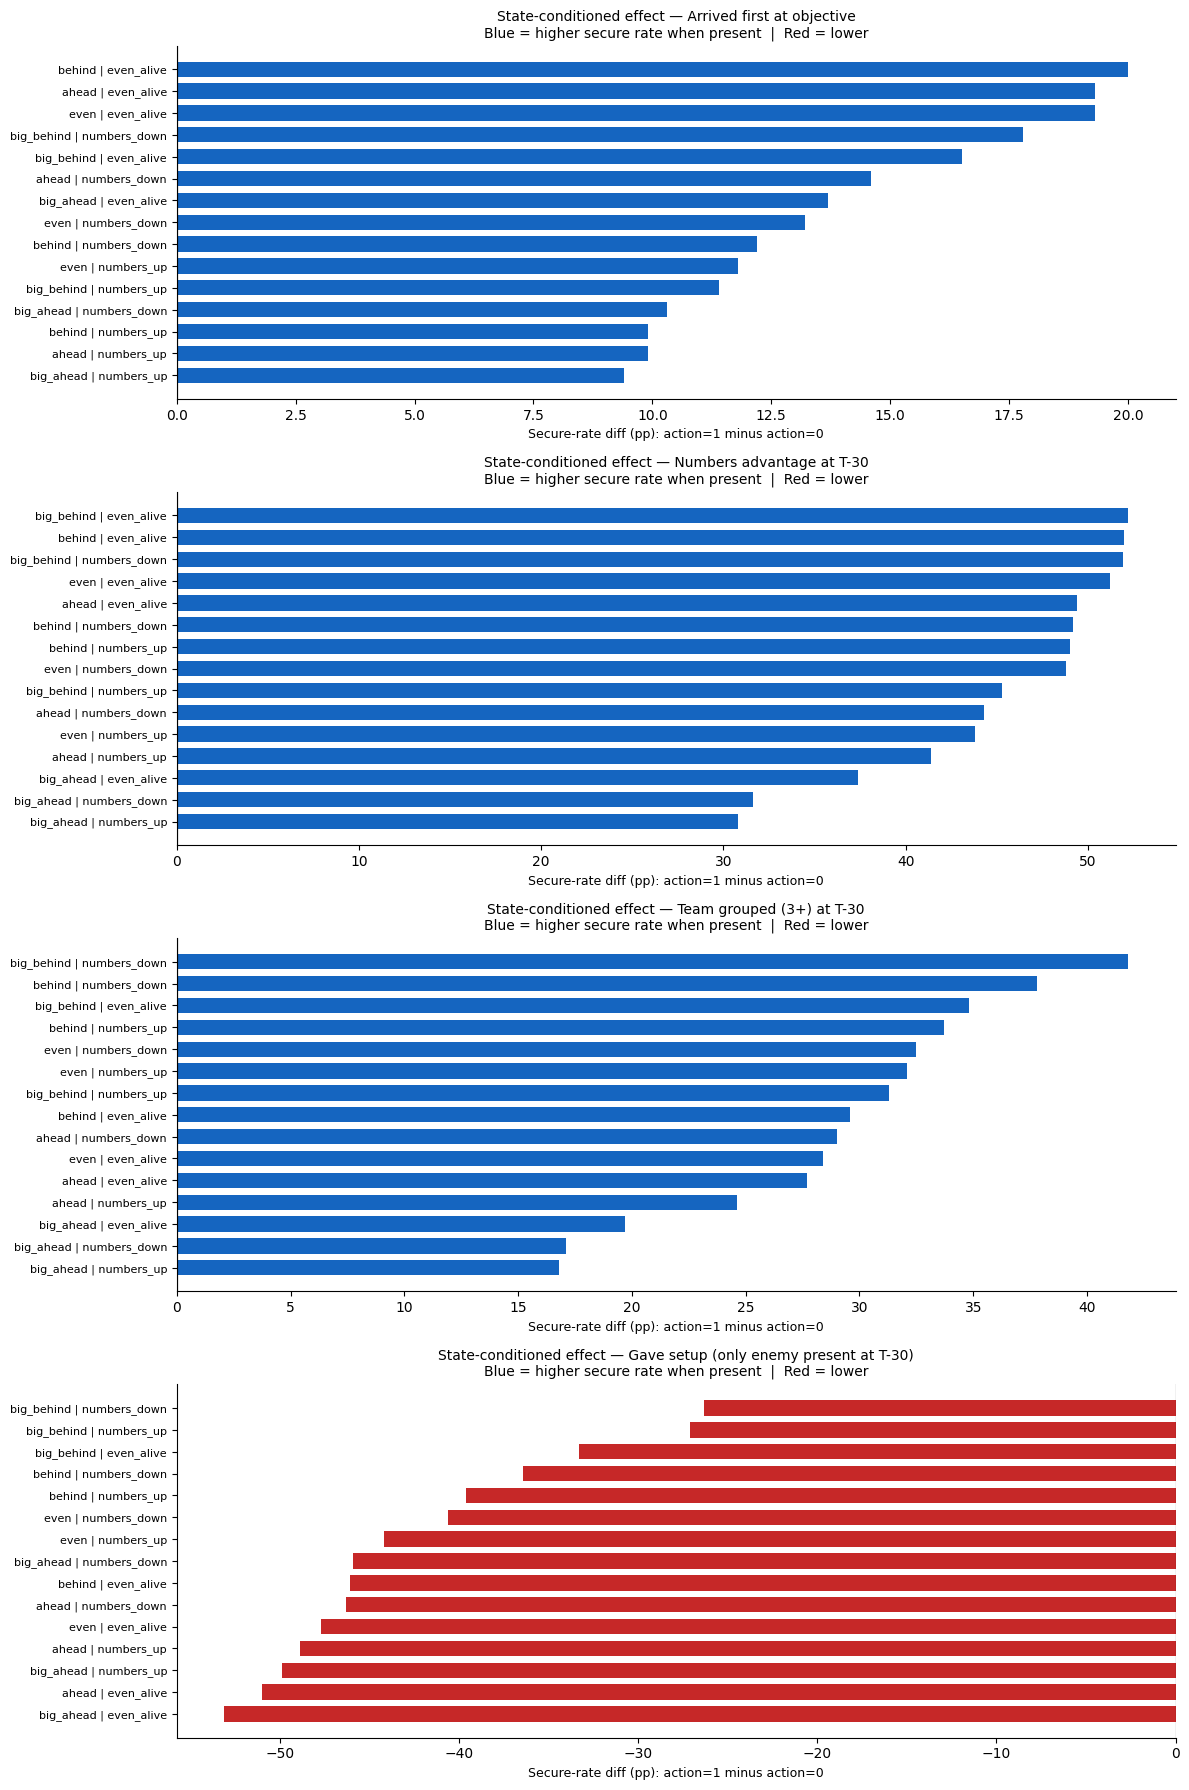

In [32]:
import matplotlib.pyplot as plt

_PLOT_ACTIONS = [
    ('arrived_first',     'Arrived first at objective'),
    ('numbers_adv_T_30',  'Numbers advantage at T-30'),
    ('team_grouped_T_30', 'Team grouped (3+) at T-30'),
    ('gave_setup_T_30',   'Gave setup (only enemy present at T-30)'),
]

_avail = [(a, lbl) for a, lbl in _PLOT_ACTIONS if a in df_sf.columns]
if not _avail:
    print('No action columns available for plots.')
else:
    fig, axes = plt.subplots(len(_avail), 1, figsize=(12, 4.5 * len(_avail)))
    if len(_avail) == 1:
        axes = [axes]

    for ax, (_act_col, _act_label) in zip(axes, _avail):
        _tbl = summarize_action_by_state(df_sf, _act_col, min_n=50)
        if _tbl.empty:
            ax.set_visible(False)
            continue

        # Top 15 by sample size, then sorted by diff_pp for readability
        _plot_tbl = (
            _tbl.nlargest(15, 'n_total')
            .sort_values('diff_pp')
            .reset_index(drop=True)
        )
        _colors = ['#c62828' if v < 0 else '#1565c0' for v in _plot_tbl['diff_pp']]
        ax.barh(range(len(_plot_tbl)), _plot_tbl['diff_pp'].values,
                color=_colors, height=0.7, edgecolor='none')
        ax.set_yticks(range(len(_plot_tbl)))
        ax.set_yticklabels(_plot_tbl['state_bucket'].values, fontsize=8)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Secure-rate diff (pp): action=1 minus action=0', fontsize=9)
        ax.set_title(
            f'State-conditioned effect — {_act_label}\n'
            f'Blue = higher secure rate when present  |  Red = lower',
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import numpy as np

print('=' * 62)
print('Propensity-style check: arrived_first')
print('=' * 62)
print('This is a propensity-style observational check — not causal.')
print()
print('Method:')
print('  1. Predict arrived_first using only T-60 state features.')
print('  2. Bin rows by predicted propensity (deciles).')
print('  3. Within each decile, compare secure rate for')
print('     arrived_first=1 vs arrived_first=0.')
print('  4. Teams in the same decile had similar observable T-60 states')
print('     but different arrival outcomes — a stronger comparison than')
print('     a raw secure-rate split.\n')

_PROP_TARGET = 'arrived_first'
if _PROP_TARGET not in df_sf.columns:
    print(f"Column '{_PROP_TARGET}' not found — skipping.")
else:
    _prop_cat_ohe = (
        pd.get_dummies(df_sf[_SF60_CAT_COLS], drop_first=False).astype(float)
        if _SF60_CAT_COLS else pd.DataFrame(index=df_sf.index)
    )
    _prop_X = pd.concat(
        [df_sf[_SF60_NUM_COLS].fillna(0).astype(float), _prop_cat_ohe], axis=1
    )
    _prop_y = df_sf[_PROP_TARGET].fillna(0).astype(int).values

    _prop_gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    _p_tr, _p_te = next(_prop_gss.split(_prop_X, _prop_y, groups))

    _prop_sc = StandardScaler()
    _prop_lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    _prop_lr.fit(_prop_sc.fit_transform(_prop_X.iloc[_p_tr].values), _prop_y[_p_tr])

    # Score all rows for binning
    _prop_scores = _prop_lr.predict_proba(
        _prop_sc.transform(_prop_X.fillna(0).values)
    )[:, 1]
    df_sf['prop_arrived_first'] = _prop_scores
    df_sf['prop_decile'] = pd.qcut(
        df_sf['prop_arrived_first'], q=10, labels=False, duplicates='drop'
    )

    _prop_rows = []
    for _dec, _grp in df_sf.groupby('prop_decile'):
        _g0 = _grp[_grp[_PROP_TARGET] == 0]
        _g1 = _grp[_grp[_PROP_TARGET] == 1]
        if len(_g0) < 5 or len(_g1) < 5:
            continue
        _r0, _r1 = float(_g0['secured'].mean()), float(_g1['secured'].mean())
        _lo = float(_grp['prop_arrived_first'].min())
        _hi = float(_grp['prop_arrived_first'].max())
        _prop_rows.append({
            'propensity_bin': f'{_lo:.2f}\u2013{_hi:.2f}',
            'n0': len(_g0), 'rate0': round(_r0 * 100, 1),
            'n1': len(_g1), 'rate1': round(_r1 * 100, 1),
            'diff_pp': round((_r1 - _r0) * 100, 1),
        })

    _prop_df = pd.DataFrame(_prop_rows)
    print(f"{'propensity_bin':<18}  {'n0':>5}  {'rate0':>6}  {'n1':>5}  {'rate1':>6}  {'diff_pp':>8}")
    print('-' * 60)
    for _, _row in _prop_df.iterrows():
        print(f"  {_row['propensity_bin']:<16}  {_row['n0']:>5}  {_row['rate0']:>5.1f}%  "
              f"{_row['n1']:>5}  {_row['rate1']:>5.1f}%  {_row['diff_pp']:>+8.1f}")

    if len(_prop_df) > 0:
        _total_n = _prop_df['n0'] + _prop_df['n1']
        _w_diff  = (_prop_df['diff_pp'] * _total_n).sum() / _total_n.sum()
        print(f'\nWeighted average diff across deciles: {_w_diff:+.1f} pp')
        print('\nNote: this is a propensity-style observational check.')
        print('Teams that tend to arrive first also differ on unmeasured factors')
        print('(champion kit, wave state, communication) that the T-60 model cannot capture.')

Propensity-style check: arrived_first
This is a propensity-style observational check — not causal.

Method:
  1. Predict arrived_first using only T-60 state features.
  2. Bin rows by predicted propensity (deciles).
  3. Within each decile, compare secure rate for
     arrived_first=1 vs arrived_first=0.
  4. Teams in the same decile had similar observable T-60 states
     but different arrival outcomes — a stronger comparison than
     a raw secure-rate split.

propensity_bin         n0   rate0     n1   rate1   diff_pp
------------------------------------------------------------
  0.03–0.14          6192   19.0%    642   33.0%     +14.0
  0.14–0.17          5833   27.1%   1000   35.1%      +8.0
  0.17–0.19          5578   32.3%   1255   42.4%     +10.1
  0.19–0.22          5419   39.1%   1415   51.7%     +12.7
  0.22–0.24          5220   46.1%   1613   57.6%     +11.5
  0.24–0.26          5049   50.7%   1784   65.5%     +14.8
  0.26–0.29          4934   53.2%   1900   66.6%     +13.4


In [34]:
def analyze_game_state_first(match_id: str) -> None:
    """Per-objective state-first breakdown for one match.

    For each objective and team side, prints:
      - T-60 state bucket (pre-commitment situation)
      - T-30 setup / action summary
      - State-only predicted secure probability
      - State+setup predicted secure probability
      - Setup swing (difference in pp)
      - Actual outcome
    """
    import math
    _rows = df_sf[df_sf['match_id'] == match_id].copy()
    if _rows.empty:
        print(f'match_id {match_id!r} not found in df_sf.')
        return

    _n_obj = _rows['objective_instance'].nunique()
    print(f'Match {match_id}  ({_n_obj} objectives)\n')

    for _inst in sorted(_rows['objective_instance'].unique()):
        _obj   = _rows[_rows['objective_instance'] == _inst].sort_values('team_side')
        _otype = _obj['objective_type'].iloc[0]
        _onum  = int(_obj['objective_number'].iloc[0])

        print('=' * 62)
        print(f'{_otype} #{_onum}')
        print('=' * 62)

        for _, _r in _obj.iterrows():
            _side  = str(_r.get('team_side', 'unknown')).upper()
            _state = str(_r.get('state_bucket_T_60', 'N/A'))
            _pst   = _r.get('sf_prob_state', float('nan'))
            _pb    = _r.get('sf_prob_both',  float('nan'))
            _sw    = _r.get('sf_swing_pp',   float('nan'))

            # Summarize setup actions
            _acts = []
            if _r.get('arrived_first') == 1:
                _acts.append('arrived first')
            if _r.get('free_setup_T_30') == 1:
                _acts.append('free setup (enemy absent)')
            elif _r.get('gave_setup_T_30') == 1:
                _acts.append('gave setup (team absent)')
            if _r.get('numbers_adv_T_30') == 1:
                _acts.append('numbers advantage')
            elif _r.get('numbers_down_T_30') == 1:
                _acts.append('numbers disadvantage')
            _tn = _r.get('team_nearby_T_30', '?')
            _en = _r.get('enemy_nearby_T_30', '?')
            _acts.append(f'{_tn} allied vs {_en} enemy nearby at T-30')

            _secured_str = 'SECURED' if _r.get('secured') else 'not secured'

            print(f'  {_side} (team {int(_r["team_id"])})')
            print(f'  T-60 state   : {_state}')
            _acts_str = ", ".join(_acts) if _acts else "N/A"
            print(f"  Setup (T-30) : {_acts_str}")
            _has_pred = not (isinstance(_pst, float) and math.isnan(_pst))
            if _has_pred:
                print(f'  State-only   : {_pst * 100:.0f}% predicted secure')
                print(f'  State+setup  : {_pb  * 100:.0f}% predicted secure')
                _sw_str = f'{_sw:+.0f} pp'
                print(f'  Setup swing  : {_sw_str}')
            print(f'  Actual       : {_secured_str}  |  outcome: {_r.get("outcome_label", "N/A")}')
            print()
        print()


_sf_demo_id = df_sf['match_id'].iloc[0]
print(f"Demo: analyze_game_state_first('{_sf_demo_id}')")
print()
analyze_game_state_first(_sf_demo_id)

Demo: analyze_game_state_first('EUW1_7108550527')

Match EUW1_7108550527  (14 objectives)

BARON_NASHOR #1
  BLUE (team 100)
  T-60 state   : ahead | numbers_up
  Setup (T-30) : free setup (enemy absent), numbers advantage, 1 allied vs 0 enemy nearby at T-30
  State-only   : 29% predicted secure
  State+setup  : 64% predicted secure
  Setup swing  : +35 pp
  Actual       : not secured  |  outcome: won_fight_lost_objective

  RED (team 200)
  T-60 state   : behind | numbers_down
  Setup (T-30) : gave setup (team absent), numbers disadvantage, 0 allied vs 1 enemy nearby at T-30
  State-only   : 54% predicted secure
  State+setup  : 23% predicted secure
  Setup swing  : -31 pp
  Actual       : SECURED  |  outcome: objective_steal


BARON_NASHOR #2
  BLUE (team 100)
  T-60 state   : even | numbers_up
  Setup (T-30) : arrived first, numbers advantage, 4 allied vs 3 enemy nearby at T-30
  State-only   : 93% predicted secure
  State+setup  : 94% predicted secure
  Setup swing  : +2 pp
  Actua

### Summary and interpretation

**State-first analysis should be read as:** among objective opportunities where teams were in similar pre-objective situations (T-60 state), these setup choices were associated with better or worse secure rates. This is stronger than raw correlation because it respects temporal order and compares more similar situations — but it is still observational.

**What the analysis cannot prove:** that a team *would have* secured the objective if they had made a different setup choice. Teams that arrive first may do so because they have an unmeasured champion advantage (e.g., better engage range) that also makes them more likely to win fights. The propensity-style check partially addresses this by comparing teams with similar predicted propensities to arrive — but unmeasured confounders remain.

**Strongest signals to look for:**
- If `arrived_first` shows large positive `diff_pp` within similar-state buckets, arrival timing adds value beyond the pre-objective game state.
- If `gave_setup_T_30` shows positive `diff_pp` in 'ahead' states, some teams may be correctly choosing to give and trade.
- If `numbers_adv_T_30` shows near-zero effect, the gold/alive state at T-60 may already capture most variance.

**Use `analyze_game_state_first(match_id)` to inspect specific games.** The 'setup swing' column shows how much the realized setup shifted the predicted probability relative to the pure T-60 state — a +20 pp swing means that team's setup choices were associated with a 20-point higher secure probability than their T-60 state alone would predict.

Run `analyze_game_state_first(df['match_id'].sample(1).iloc[0])` to explore a random match.

## Advanced Visualizations: Gold Breakeven, Setup Flow, and State-Action-Outcome Sankeys

Three complementary analyses connecting pre-objective conditions to results:

1. **Gold breakeven by setup profile** — logistic regression curves showing how gold advantage shifts the secure rate for each profile; diamonds mark the gold difference where each profile crosses 50%.
2. **Sankey: Setup Profile → Outcome** — how each type of pre-objective positioning leads to specific outcomes.
3. **Sankey: Gold State → Setup Profile → Outcome** — the full decision chain from gold advantage at T-60, through setup choice at T-30, to objective result.

In [35]:
import sys
import warnings
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
if "../src" not in sys.path:
    sys.path.insert(0, "../src")

from lolobj.analysis.baseline_report import assign_setup_profiles, PROFILE_ORDER, OUTCOME_ORDER
from lolobj.analysis.state_first import make_state_first_frame

_df_raw = pd.read_parquet("../data/processed/objective_windows.parquet")
df = _df_raw[_df_raw["objective_type"] == "DRAGON"].copy()
df["setup_profile"] = assign_setup_profiles(df)
df = make_state_first_frame(df)

GOLD_STATE_ORDER = ["big_behind", "behind", "even", "ahead", "big_ahead"]

print(f"Dragon rows: {len(df):,}")
print("\nSetup profiles:")
print(df["setup_profile"].value_counts().to_string())
print("\nOutcome labels:")
print(df["outcome_label"].value_counts().to_string())
if "gold_state_T_60" in df.columns:
    print("\nGold states (T-60):")
    print(df["gold_state_T_60"].value_counts().to_string())


  [state_first] NOTE: enemy_deaths_90s absent; using enemy_deaths_60s as fallback for death_state_pre_obj.
Dragon rows: 30,034

Setup profiles:
setup_profile
gave_away            7249
disadvantaged        7048
both_absent          4846
clean_contest        3642
free_setup_deaths    3631
free_setup           3618

Outcome labels:
outcome_label
clean_take                  6940
no_meaningful_contest       4846
clean_give                  4172
throw_setup                 3217
good_trade                  2662
lost_fight_got_objective    2444
coinflip                    1915
won_fight_lost_objective    1327
objective_steal             1295
bad_contest                 1216

Gold states (T-60):
gold_state_T_60
big_behind    6039
behind        6025
ahead         6014
big_ahead     5984
even          5972


In [36]:
# ── Gold Breakeven Analysis ───────────────────────────────────────────────────
# For each setup profile, fit logistic regression: P(secure) ~ gold_diff_T_60.
# Breakeven: logit = 0  →  gold_diff = −intercept / coef.
# Profiles with extreme base rates may not cross 50% within the observed data range.

PROFILE_COLORS = {
    "free_setup":        "#00CC96",
    "free_setup_deaths": "#7DCC9E",
    "clean_contest":     "#636EFA",
    "disadvantaged":     "#EF553B",
    "gave_away":         "#AAAAAA",
    "no_early_setup":       "#DDDDDD",
}

g_lo = float(df["gold_diff_T_60"].quantile(0.02))
g_hi = float(df["gold_diff_T_60"].quantile(0.98))
gold_range = np.linspace(g_lo, g_hi, 400)

fig_be = go.Figure()
summary_rows = []

for profile in PROFILE_ORDER:
    sub = df[df["setup_profile"] == profile].dropna(subset=["gold_diff_T_60", "secured"])
    if len(sub) < 30:
        continue
    color = PROFILE_COLORS.get(profile, "#888888")
    X = sub[["gold_diff_T_60"]].values
    y = sub["secured"].values.astype(int)

    lr = LogisticRegression(max_iter=1000)
    lr.fit(X, y)
    coef      = float(lr.coef_[0][0])
    intercept = float(lr.intercept_[0])
    breakeven = (-intercept / coef) if coef != 0 else None
    base_rate = float(lr.predict_proba([[0]])[0, 1])

    y_pred = lr.predict_proba(gold_range.reshape(-1, 1))[:, 1]
    fig_be.add_trace(go.Scatter(
        x=gold_range, y=y_pred,
        name=profile,
        mode="lines",
        line=dict(color=color, width=2.5),
        hovertemplate=(
            f"<b>{profile}</b><br>"
            "Gold diff: %{x:+,.0f}<br>"
            "P(secure): %{y:.1%}<extra></extra>"
        ),
    ))

    if breakeven is not None:
        fig_be.add_trace(go.Scatter(
            x=[breakeven], y=[0.5],
            mode="markers+text",
            marker=dict(color=color, size=13, symbol="diamond",
                        line=dict(color="white", width=1.5)),
            text=[f"{breakeven:+,.0f}g"],
            textposition="top center",
            textfont=dict(size=10, color=color),
            showlegend=False,
            hovertemplate=(
                f"<b>{profile}</b> breakeven<br>"
                f"Gold diff: {breakeven:+,.0f}g<extra></extra>"
            ),
        ))
        be_str = f"{breakeven:+,.0f}g"
    else:
        be_str = "flat"

    summary_rows.append({
        "Profile":             profile,
        "N":                   len(sub),
        "Base rate @ 0g diff": f"{base_rate:.1%}",
        "50% breakeven gold":  be_str,
    })

fig_be.add_hline(
    y=0.5, line_dash="dash", line_color="rgba(200,200,200,0.5)", line_width=1.5,
    annotation_text="50% threshold", annotation_position="right",
)
fig_be.add_vline(x=0, line_dash="dot", line_color="rgba(180,180,180,0.35)", line_width=1)

fig_be.update_layout(
    title=dict(
        text=(
            "Gold Difference vs. Secure Rate by Setup Profile<br>"
            "<sub>Diamonds mark the breakeven gold diff where P(secure) = 50%</sub>"
        ),
        x=0.5,
    ),
    xaxis=dict(title="Gold Difference at T-60 (team \u2212 enemy)", tickformat="+,"),
    yaxis=dict(title="P(Secure Objective)", tickformat=".0%", range=[0, 1]),
    template="plotly_dark",
    width=960, height=580,
    legend=dict(x=1.01, y=0.5, xanchor="left", bgcolor="rgba(0,0,0,0)"),
    margin=dict(r=200),
)
fig_be.show()

print("\nBreakeven summary:")
print(pd.DataFrame(summary_rows).to_string(index=False))



Breakeven summary:
          Profile    N Base rate @ 0g diff 50% breakeven gold
      both_absent 4846               50.0%                -0g
        gave_away 7249               16.3%            +7,137g
       free_setup 3618               89.6%            -9,692g
free_setup_deaths 3631               78.3%            -5,950g
    clean_contest 3642               68.7%            -3,904g
    disadvantaged 7048               40.4%            +2,624g


In [37]:
# ── Sankey: Setup Profile → Outcome Label ────────────────────────────────────

def _hex_rgba(hex_color: str, alpha: float = 0.38) -> str:
    h = hex_color.lstrip("#")
    return f"rgba({int(h[0:2], 16)},{int(h[2:4], 16)},{int(h[4:6], 16)},{alpha})"

SETUP_COLORS = {
    "free_setup":        "#00CC96",
    "free_setup_deaths": "#7DCC9E",
    "clean_contest":     "#636EFA",
    "disadvantaged":     "#EF553B",
    "gave_away":         "#AAAAAA",
    "no_early_setup":       "#DDDDDD",
}
OUTCOME_COLORS = {
    "clean_take":               "#00CC96",
    "clean_give":               "#19D3F3",
    "good_trade":               "#66BB66",
    "coinflip":                 "#FFA15A",
    "throw_setup":              "#FF6633",
    "bad_contest":              "#CC1111",
    "won_fight_lost_objective": "#FFD700",
    "lost_fight_got_objective": "#FF9933",
    "objective_steal":          "#AB63FA",
    "no_meaningful_contest":    "#AAAAAA",
}

p_setups   = [p for p in PROFILE_ORDER  if p in df["setup_profile"].unique()]
p_outcomes = [o for o in OUTCOME_ORDER  if o in df["outcome_label"].unique()]

all_labels  = p_setups + p_outcomes
node_idx    = {l: i for i, l in enumerate(all_labels)}
node_colors = (
    [SETUP_COLORS.get(p, "#888") for p in p_setups]
    + [OUTCOME_COLORS.get(o, "#888") for o in p_outcomes]
)

counts = (
    df.groupby(["setup_profile", "outcome_label"])
    .size()
    .reset_index(name="n")
)
counts = counts[
    counts["setup_profile"].isin(p_setups)
    & counts["outcome_label"].isin(p_outcomes)
    & (counts["n"] >= 3)
]

src4, tgt4, val4, lc4 = [], [], [], []
for _, row in counts.iterrows():
    src4.append(node_idx[row["setup_profile"]])
    tgt4.append(node_idx[row["outcome_label"]])
    val4.append(int(row["n"]))
    lc4.append(_hex_rgba(SETUP_COLORS.get(row["setup_profile"], "#888"), 0.30))

fig_s2 = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        pad=15, thickness=22,
        label=all_labels, color=node_colors,
        line=dict(color="rgba(0,0,0,0)", width=0),
        hovertemplate="%{label}<br>Total: %{value:,}<extra></extra>",
    ),
    link=dict(
        source=src4, target=tgt4, value=val4, color=lc4,
        hovertemplate="%{source.label} \u2192 %{target.label}<br>Count: %{value:,}<extra></extra>",
    ),
))
fig_s2.update_layout(
    title=dict(text="Setup Profile \u2192 Outcome Label (Dragon objectives)", x=0.5),
    template="plotly_dark",
    width=960, height=660,
    font=dict(size=12),
)
fig_s2.show()


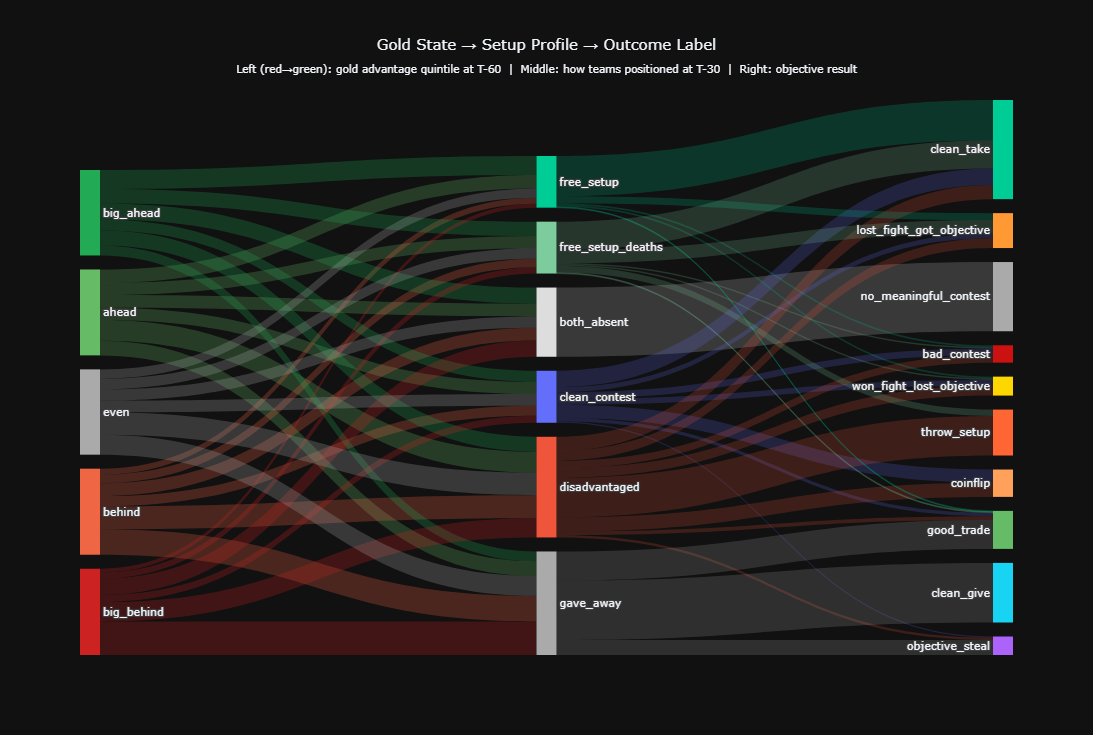

In [38]:
# ── Sankey: Gold State → Setup Profile → Outcome Label ───────────────────────
# 3-layer flow: gold advantage at T-60 → setup choice at T-30 → outcome.
# Depends on: GOLD_STATE_ORDER, p_setups, p_outcomes, SETUP_COLORS, OUTCOME_COLORS,
#             _hex_rgba  (all defined in the preceding two cells).

GOLD_STATE_COLORS_MAP = {
    "big_behind": "#CC2222",
    "behind":     "#EF6644",
    "even":       "#AAAAAA",
    "ahead":      "#66BB66",
    "big_ahead":  "#22AA55",
}

df_gs = df.dropna(subset=["gold_state_T_60"]).copy()
df_gs = df_gs[df_gs["gold_state_T_60"].isin(GOLD_STATE_ORDER)]

p_states = [s for s in GOLD_STATE_ORDER if s in df_gs["gold_state_T_60"].unique()]

gs_labels = p_states + p_setups + p_outcomes
gs_idx    = {l: i for i, l in enumerate(gs_labels)}
gs_node_colors = (
    [GOLD_STATE_COLORS_MAP.get(s, "#888") for s in p_states]
    + [SETUP_COLORS.get(p, "#888") for p in p_setups]
    + [OUTCOME_COLORS.get(o, "#888") for o in p_outcomes]
)

# Layer 1: gold_state → setup_profile
l1 = df_gs.groupby(["gold_state_T_60", "setup_profile"]).size().reset_index(name="n")
l1 = l1[l1["setup_profile"].isin(p_setups) & (l1["n"] >= 5)]

# Layer 2: setup_profile → outcome_label (same filtered frame)
l2 = df_gs.groupby(["setup_profile", "outcome_label"]).size().reset_index(name="n")
l2 = l2[l2["outcome_label"].isin(p_outcomes) & (l2["n"] >= 5)]

src5, tgt5, val5, lc5 = [], [], [], []
for _, row in l1.iterrows():
    s, t, v = row["gold_state_T_60"], row["setup_profile"], int(row["n"])
    if s in gs_idx and t in gs_idx:
        src5.append(gs_idx[s]); tgt5.append(gs_idx[t]); val5.append(v)
        lc5.append(_hex_rgba(GOLD_STATE_COLORS_MAP.get(s, "#888"), 0.26))

for _, row in l2.iterrows():
    s, t, v = row["setup_profile"], row["outcome_label"], int(row["n"])
    if s in gs_idx and t in gs_idx:
        src5.append(gs_idx[s]); tgt5.append(gs_idx[t]); val5.append(v)
        lc5.append(_hex_rgba(SETUP_COLORS.get(s, "#888"), 0.20))

fig_s3 = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        pad=14, thickness=20,
        label=gs_labels, color=gs_node_colors,
        line=dict(color="rgba(0,0,0,0)", width=0),
        hovertemplate="%{label}<br>Total flow: %{value:,}<extra></extra>",
    ),
    link=dict(
        source=src5, target=tgt5, value=val5, color=lc5,
        hovertemplate="%{source.label} \u2192 %{target.label}<br>Count: %{value:,}<extra></extra>",
    ),
))
fig_s3.update_layout(
    title=dict(
        text=(
            "Gold State \u2192 Setup Profile \u2192 Outcome Label<br>"
            "<sub>"
            "Left (red\u2192green): gold advantage quintile at T-60  |  "
            "Middle: how teams positioned at T-30  |  "
            "Right: objective result"
            "</sub>"
        ),
        x=0.5,
    ),
    template="plotly_dark",
    width=1100, height=720,
    font=dict(size=11),
)
fig_s3.show()
